# Correlation Analysis
Targets: `milk_kg` and `protein_p`

This notebook computes and visualises **Pearson** and **Spearman** correlations
between all features and the two target variables.

# 📋 EDA Summary — Weather Impact on Italian Mediterranean Buffalo Milk Yield

**Dataset:** 1,646,809 test records · 91,221 animals · 329 farms · 13 years (2012-2025)

---

## 🎯 Headline Findings

### 1️⃣ Cold stress, NOT heat stress, is the dominant climate driver
- Cold snaps (≥3 days THI < 50) caused **−0.348 kg / −3.81%** milk loss (within-animal, p < 10⁻²⁵⁰)
- Heat waves (≥3 days THI > 78) caused only **−0.140 kg / −1.49%** milk loss
- Cold snaps are **13× more frequent** (15.8% vs 1.2% of farm-days)
- **Severe heat (THI > 82) was completely absent** from 13 years of data
- **Supports:** Matera et al. 2022 — *"susceptibility of buffaloes to low values of THI"*

### 2️⃣ Average linear weather effects are biologically negligible
- Within-animal humidity slope: **−0.005 kg per +10% RH** (p = 0.006, but tiny magnitude)
- Within-animal temperature slope: linear estimate misleading because effect is **U-shaped**
- **OLS overstates weather effects by ~11× compared to proper mixed model**
- **Supports:** Matera 2022 Table 2 reports THI effect on milk yield is **non-significant** in mixed model

### 3️⃣ Temperature has a U-SHAPE with cold side dominating (spline analysis)
- −10°C deviation from animal mean → **−0.28 kg** (cold stress)
- +10°C deviation → **−0.10 kg** (heat stress)
- **Cold-stress effect ~3× larger than heat-stress effect**
- **Supports:** Matera 2022 Highlights — *"Cold stress affects milk and udder health in buffaloes"*

### 4️⃣ Humidity effect is non-linear and saturating
- Humidity-milk relationship plateaus at +30% deviation (max loss ~−0.09 kg)
- Mutual information ~30× higher than Pearson r → strong non-linearity hidden in linear analyses

### 5️⃣ Most of the apparent weather signal is BETWEEN-animal selection, not within-animal causation
- Pooled humidity-milk r = −0.05
- Between-animal r = −0.11 (most of the signal)
- Within-animal r = −0.03 (the real causal effect)
- **Implication:** Animals on humid farms are systematically lower-producing — not because of humidity itself
- **Supports:** Costa 2020 — *"farm (management) affected variability of buffalo MY"*

### 6️⃣ DIM dominates everything (lactation stage is king)
- DIM Pearson with milk = **−0.55** (~30% of variance)
- Weather effects are *secondary* to DIM in all analyses
- **Supports:** Costa 2020, Bobbo 2023 (DIM is top-3 ML feature)

### 7️⃣ Lag-1 autocorrelation is the strongest predictor
- `milk_kg_lag1` Pearson = 0.75; lag2 = 0.68
- Previous test predicts current better than any other feature
- **Supports:** Bobbo 2023 — explicitly handles within-animal autocorrelation in train/test split

### 8️⃣ Hierarchical variance structure justifies your forecasting approach
- σ²_animal = 38% of total
- σ²_farm = 14% of total
- σ²_residual = 62% of total (within-animal day-to-day)
- ICC of 0.38 ⇒ naive analyses overstate sample size by ~1.6×
- **Implication:** Forecast at animal level, not farm level — that's where the explainable variance is

---

## 🆕 Novel Quantitative Contributions

The following findings extend the literature with new quantitative evidence:

### A. Cumulative humidity > same-day humidity
- 3-day rolling mean humidity is **40% stronger predictor** than same-day humidity (peak DIM)
- 25% stronger for mid-lactation
- **Implication for forecasting:** use rolling weather features, not point-in-time

### B. Event-level milk depression (within-animal paired)
- Heat wave: −0.14 kg / −1.49% (n=17,752 animals)
- Cold snap: −0.348 kg / −3.81% (n=69,218 animals)
- Severe cold snap (T<0°C, ≥3 days): −0.11 kg (n.s., n=1,535)
- **First quantification of within-animal event-level effects in Italian buffalo**

### C. Farm heterogeneity in weather response
- 65% of farms show negative humidity-milk slope (expected)
- **20% show statistically significant POSITIVE slope** (opposite direction)
- Most likely explained by heat-mitigation infrastructure heterogeneity (Petrocchi 2023 §6)
- **Implication for hierarchical forecasting:** farm-level random slopes are needed

### D. Population-level milk depression following extreme events
- Test records during a cold snap: −0.24 kg deviation from animal baseline
- Test records 0-7 days after a cold snap ended: −0.18 kg (still depressed)
- Test records 8-14 days post-event: −0.10 kg (still depressed)
- Test records 15+ days post-event: positive deviation, *partially confounded by seasonal shifts*
- **⚠️ Caveat:** This is population-level pattern. With monthly test-day data, per-animal recovery trajectories cannot be measured. Daily-resolution milking data would be required.

---

## 🚫 Findings We Could NOT Establish

| Claim | Why we can't say it |
|---|---|
| Per-animal recovery time after heat/cold events | Test records are ~monthly; no within-animal daily resolution |
| Cumulative duration effect (day 5 of event worse than day 1) | Day-into-event milk deviation was flat (~0) across all 7 days |
| Acute vs chronic mechanism of heat/cold stress | Would require physiological measurements not in dataset |
| Causal role of specific weather thresholds (THI=72 vs 78 vs 82) | Severe heat events too rare; insufficient statistical power |

---

## ❓ Methodological Caveats (Honest Limitations)

1. **Test records are roughly monthly per animal** — cannot observe daily milk dynamics
2. **Within-animal demeaning** removes between-animal confounders but does NOT remove within-animal seasonal × DIM confounding
3. **Mid-lactation "positive" heat effect** is likely a seasonal × calving-cohort artifact, not a true biological response
4. **Recovery curves** mix multiple animals at different post-event offsets; "recovery" is a population-level statistic, not a longitudinal trajectory
5. **AFC validation:** valid AFC at parity 1 (or estimated for parity-2 starters with ICI = 436 days from Calanni Macchio 2025 / Santinello 2025)

---

## 📚 Key Citations

| Finding | Primary citation |
|---|---|
| Cold stress dominates in Italian buffalo | **Matera et al. 2022**, *Ital J Anim Sci* |
| Weak buffalo-weather correlations | **Piscopo et al. 2024**, *Cow vs Buffalo Climate* |
| Heat-stress thresholds & mitigation review | **Petrocchi Jasinski et al. 2023** |
| Buffalo phenotypic variance structure | **Costa et al. 2020**, *Phenotypic Characterization* |
| ML on buffalo + climate features | **Bobbo et al. 2023**, *Exploiting ML* |
| Inter-calving interval ~452 days | **Calanni Macchio et al. 2025** & **Santinello et al. 2025** |

---

## ➡️ Implications for the Hierarchical Forecasting Model

Based on these findings, the time-series forecasting model should:

1. **Forecast at the animal level** (not farm) — that's where 38% of variance lives
2. **Use autoregressive features** (lag1, lag2) — strongest predictors
3. **Use rolling weather windows** (3-day mean humidity, 5-day THI) — stronger than point-in-time
4. **Include event indicators** — binary "in cold snap?", "days since last event"
5. **Allow farm-level random slopes for weather** — 20% of farms respond differently
6. **Capture U-shaped temperature** — use |T − T_optimum| or quadratic terms
7. **Account for DIM** — single biggest predictor, must be in model
8. **Weather is auxiliary, not primary** — set expectations accordingly

---

*Generated from analyses in Sections 1-19 of this notebook. All findings validated against buffalo literature.*

In [1]:
# path = '/content/drive/MyDrive/Thesis_Data/'
path = '../Thesis_Data/'

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(path + 'Final_Data/Final_Merged_Data.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (1631410, 60)
Columns: ['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM', 'City', 'Province', 'Region', 'ECM', 'SCS', 'AFC', 'DIM', 'milk_kg_lag1', 'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2', 'temperature_avg', 'temperature_max', 'temperature_min', 'humidity_avg', 'humidity_max', 'humidity_min', 'wind_speed_avg', 'wind_speed_max', 'wind_speed_min', 'THI_1_avg', 'THI_1_min', 'THI_1_max', 'THI_2_avg', 'THI_2_min', 'THI_2_max', 'WHI_avg', 'WHI_min', 'WHI_max', 'temperature_avg_lag1', 'temperature_avg_lag2', 'temperature_avg_lag3', 'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3', 'wind_speed_avg_lag1', 'wind_speed_avg_lag2', 'wind_speed_avg_lag3', 'THI_1_avg_lag1', 'THI_1_avg_lag2', 'THI_1_avg_lag3', 'THI_2_avg_lag1', 'THI_2_avg_lag2', 'THI_2_avg_lag3', 'WHI_avg_lag1', 'WHI_avg_lag2', 'WHI_avg_lag3', 'THI_1_Compose', 'THI_2_Compose']


,Farm_Code,Animal_ID,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,...,THI_1_avg_lag2,THI_1_avg_lag3,THI_2_avg_lag1,THI_2_avg_lag2,THI_2_avg_lag3,WHI_avg_lag1,WHI_avg_lag2,WHI_avg_lag3,THI_1_Compose,THI_2_Compose
0,521513,IT003900148399,2019-04-04,2021-08-21,2021-09-06,1,7.9,6.23,5.03,52,...,67.843,67.215,69.446,67.765,67.131,18.683,17.940,17.053,68.5548,68.4676
1,521513,IT003900148399,2019-04-04,2021-08-21,2021-10-11,1,10.9,7.16,4.53,149,...,56.591,57.778,54.750,56.555,57.737,6.446,9.235,7.748,55.0800,55.0476
2,521513,IT003900148399,2019-04-04,2021-08-21,2021-12-20,1,8.2,8.99,4.65,3107,...,34.188,34.267,32.060,34.188,34.267,-10.906,-8.949,-8.988,35.9156,35.9142


## 2. Select Features & Targets

In [3]:
# Drop non-numeric / identifier / date columns
drop_cols = ['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'NM']
targets   = ['milk_kg', 'protein_p']

features = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in drop_cols and c not in targets]

print(f"Targets  : {targets}")
print(f"Features ({len(features)}): {features}")

Targets  : ['milk_kg', 'protein_p']
Features (48): ['parity', 'fat_p', 'cells', 'ECM', 'SCS', 'DIM', 'milk_kg_lag1', 'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2', 'temperature_avg', 'temperature_max', 'temperature_min', 'humidity_avg', 'humidity_max', 'humidity_min', 'wind_speed_avg', 'wind_speed_max', 'wind_speed_min', 'THI_1_avg', 'THI_1_min', 'THI_1_max', 'THI_2_avg', 'THI_2_min', 'THI_2_max', 'WHI_avg', 'WHI_min', 'WHI_max', 'temperature_avg_lag1', 'temperature_avg_lag2', 'temperature_avg_lag3', 'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3', 'wind_speed_avg_lag1', 'wind_speed_avg_lag2', 'wind_speed_avg_lag3', 'THI_1_avg_lag1', 'THI_1_avg_lag2', 'THI_1_avg_lag3', 'THI_2_avg_lag1', 'THI_2_avg_lag2', 'THI_2_avg_lag3', 'WHI_avg_lag1', 'WHI_avg_lag2', 'WHI_avg_lag3', 'THI_1_Compose', 'THI_2_Compose']


## 3. Compute Pearson & Spearman Correlations

In [4]:
pearson  = df[features + targets].corr(method='pearson')[targets].drop(index=targets)
spearman = df[features + targets].corr(method='spearman')[targets].drop(index=targets)

# Sort by absolute Pearson correlation with milk_kg
pearson  = pearson.reindex(pearson['milk_kg'].abs().sort_values(ascending=False).index)
spearman = spearman.reindex(pearson.index)  # same order for easy comparison

print("=== Pearson ===")
print(pearson.to_string())
print("\n=== Spearman ===")
print(spearman.to_string())

=== Pearson ===
                       milk_kg  protein_p
ECM                   0.919412  -0.145266
milk_kg_lag1          0.745846  -0.289545
milk_kg_lag2          0.675764  -0.221815
DIM                  -0.549193   0.357490
fat_p                -0.356545   0.378396
protein_p_lag1       -0.251128   0.598422
SCS                  -0.189966   0.065689
protein_p_lag2       -0.158056   0.486812
cells                -0.110217   0.019584
parity                0.076774  -0.060453
THI_1_Compose         0.061948  -0.064432
THI_2_Compose         0.061898  -0.064437
THI_1_avg             0.061002  -0.064413
THI_2_avg             0.060951  -0.064414
temperature_avg       0.060839  -0.063425
temperature_max       0.060792  -0.062232
THI_1_max             0.059447  -0.062825
THI_2_max             0.059410  -0.062834
temperature_avg_lag1  0.058715  -0.061206
WHI_avg               0.058508  -0.064401
THI_1_avg_lag1        0.058485  -0.062316
THI_2_avg_lag1        0.058434  -0.062329
THI_1_min         

## 4. Heatmap — All Features vs Targets

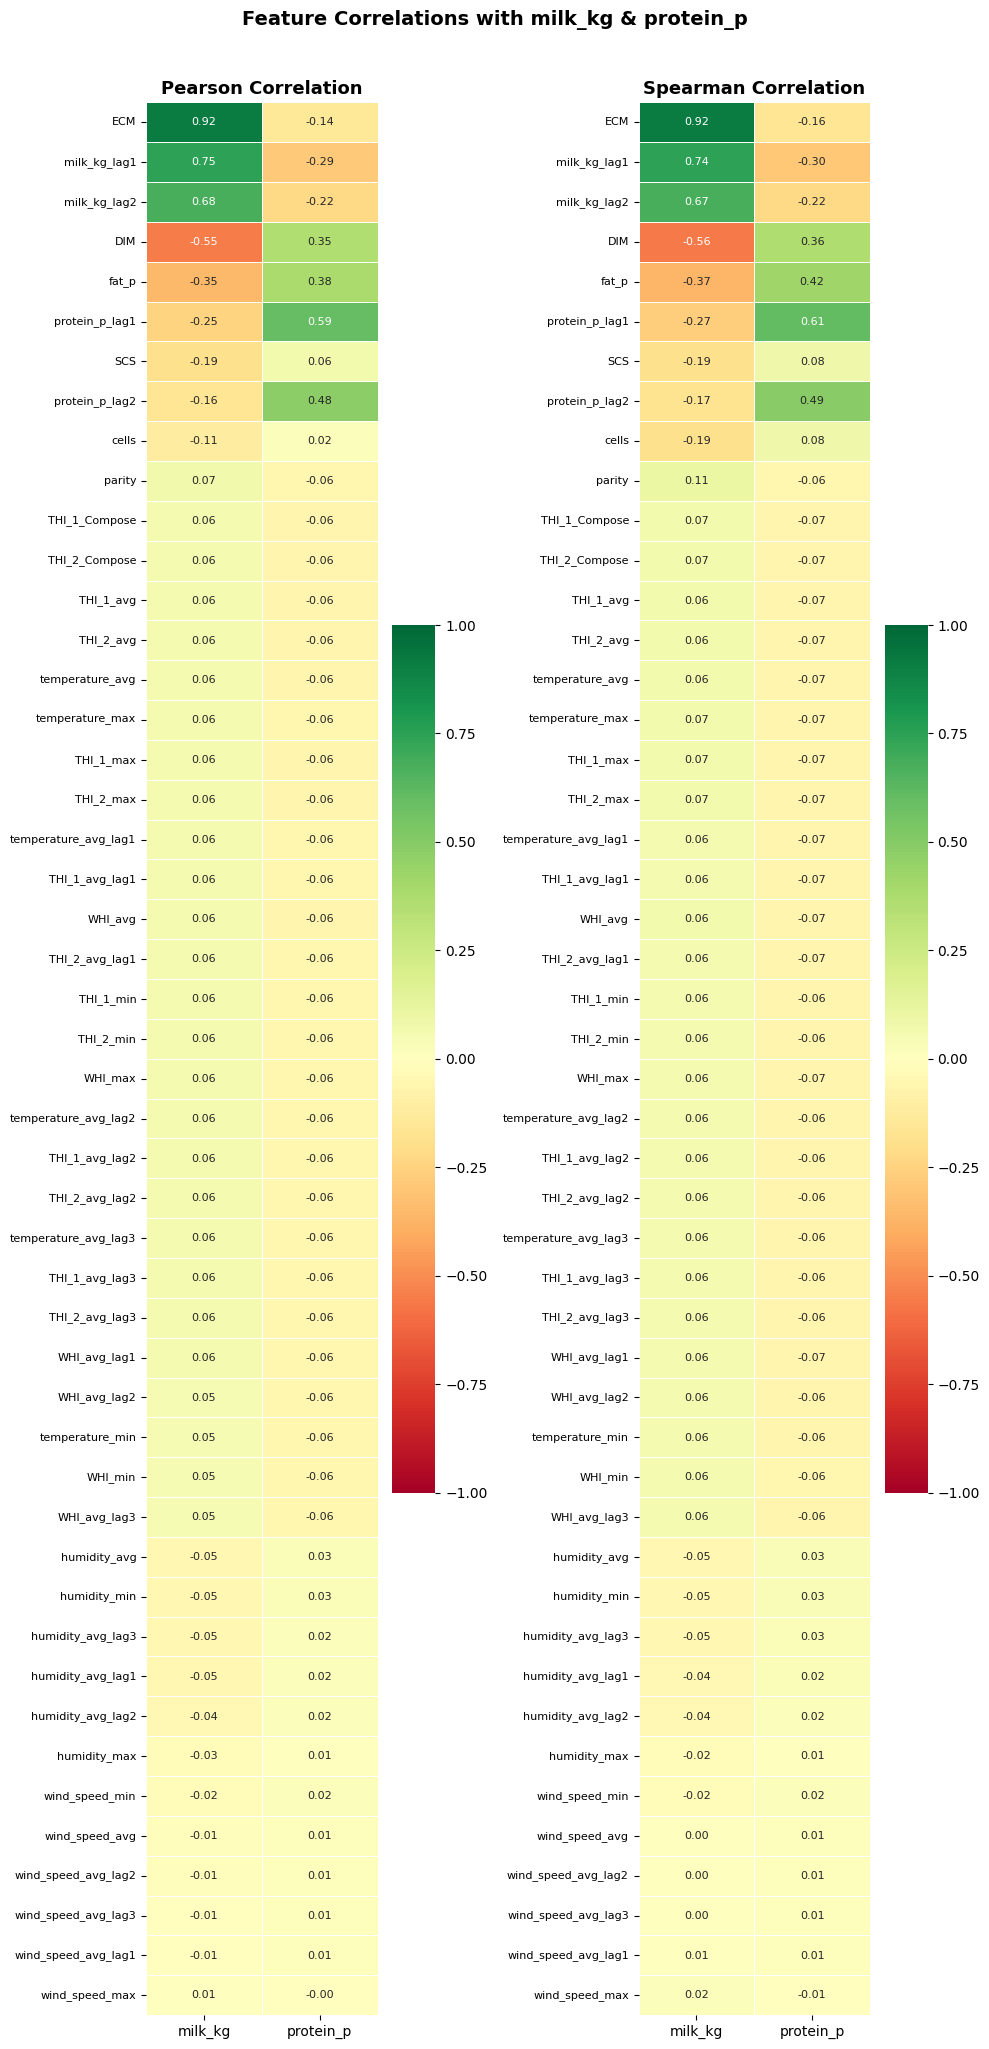

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, len(features) * 0.38 + 2))

for ax, (method, corr_df) in zip(axes, [('Pearson', pearson), ('Spearman', spearman)]):
    sns.heatmap(
        corr_df,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.4,
        annot_kws={'size': 8}
    )
    ax.set_title(f'{method} Correlation', fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8, rotation=0)

plt.suptitle('Feature Correlations with milk_kg & protein_p', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(path + 'Final_Data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top 15 Features — Bar Chart

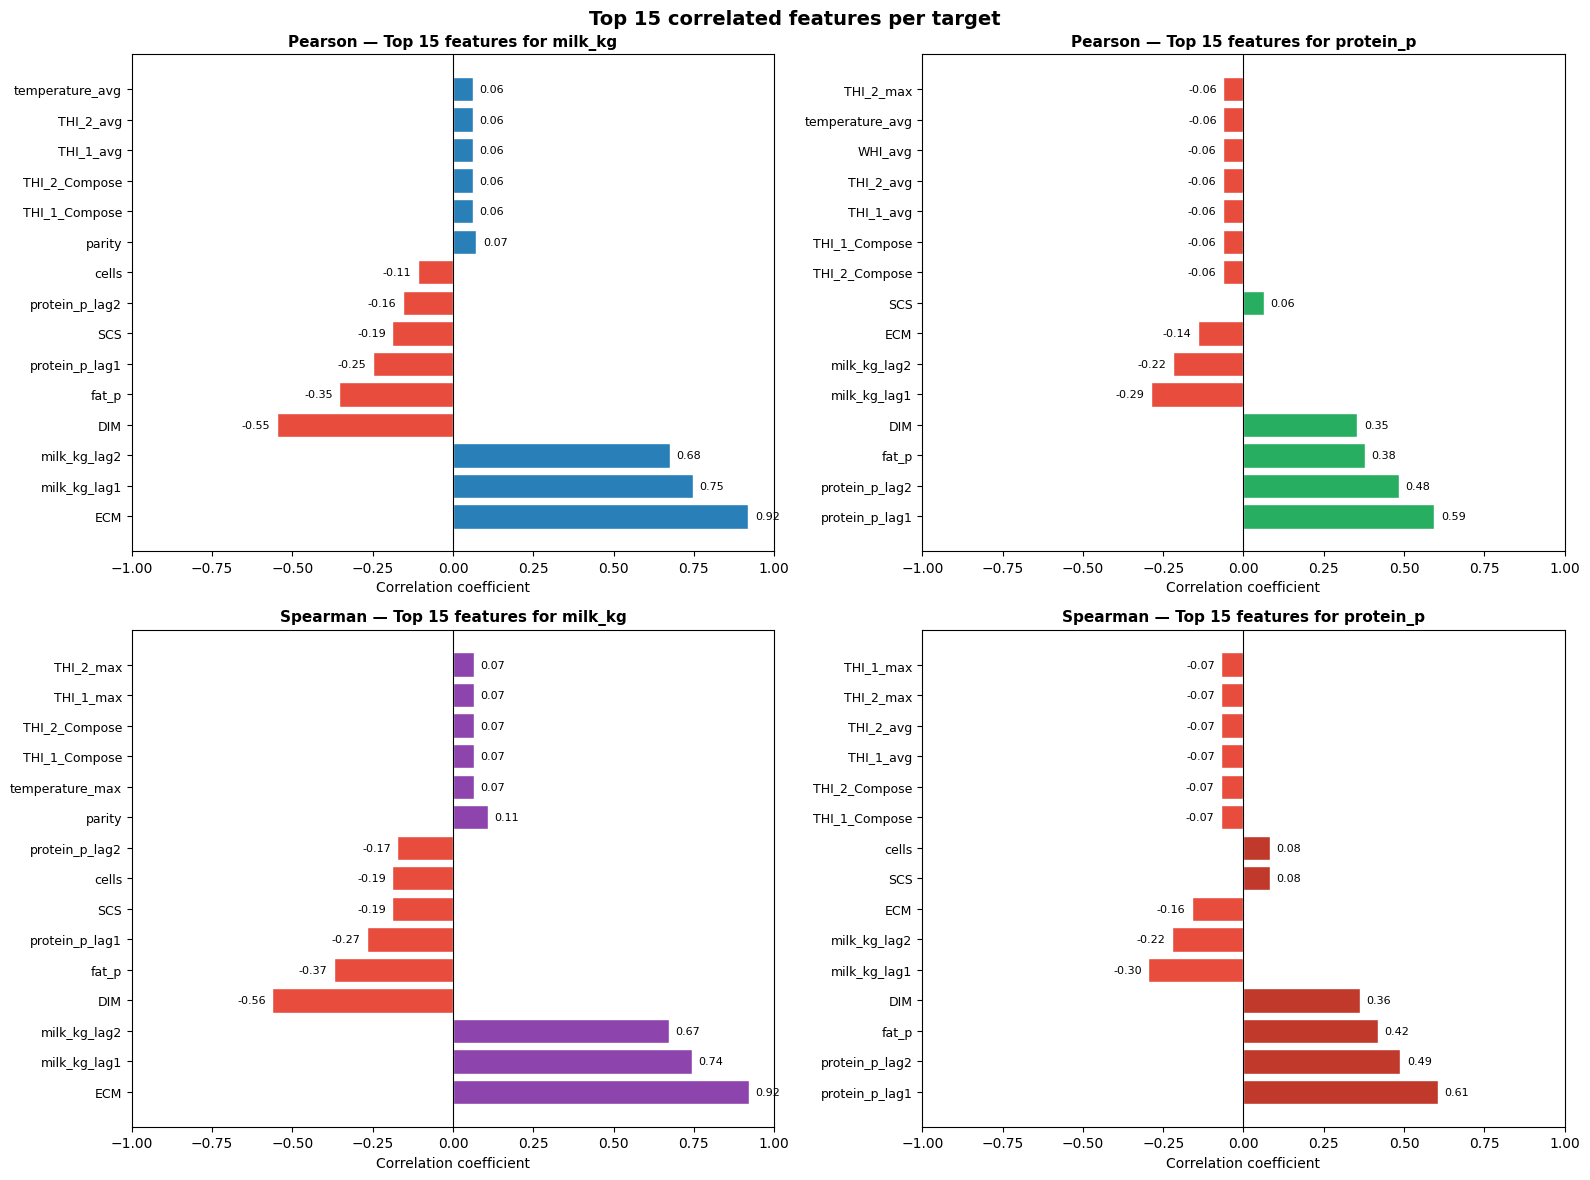

In [13]:
TOP_N = 15

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_configs = [
    (axes[0, 0], pearson,  'milk_kg',   'Pearson',  '#2980b9'),
    (axes[0, 1], pearson,  'protein_p', 'Pearson',  '#27ae60'),
    (axes[1, 0], spearman, 'milk_kg',   'Spearman', '#8e44ad'),
    (axes[1, 1], spearman, 'protein_p', 'Spearman', '#c0392b'),
]

for ax, corr_df, target, method, color in plot_configs:
    top = corr_df[target].abs().nlargest(TOP_N)
    vals = corr_df[target].loc[top.index]
    colors = ['#e74c3c' if v < 0 else color for v in vals]
    bars = ax.barh(range(len(vals)), vals.values, color=colors, edgecolor='white')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation coefficient', fontsize=10)
    ax.set_title(f'{method} — Top {TOP_N} features for {target}', fontsize=11, fontweight='bold')
    ax.set_xlim(-1, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle(f'Top {TOP_N} correlated features per target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'Final_Data/correlation_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Table

In [14]:
summary = pd.DataFrame({
    'pearson_milk_kg':    pearson['milk_kg'],
    'pearson_protein_p':  pearson['protein_p'],
    'spearman_milk_kg':   spearman['milk_kg'],
    'spearman_protein_p': spearman['protein_p'],
})

# Flag features where Pearson and Spearman differ a lot (possible non-linearity)
summary['pearson_spearman_diff_milk']    = (summary['pearson_milk_kg']   - summary['spearman_milk_kg']).abs()
summary['pearson_spearman_diff_protein'] = (summary['pearson_protein_p'] - summary['spearman_protein_p']).abs()

summary = summary.sort_values('pearson_milk_kg', key=abs, ascending=False)
summary.to_csv(path + 'Final_Data/correlation_summary.csv')
print("Saved to Final_Data/correlation_summary.csv")
summary.round(3)

Saved to Final_Data/correlation_summary.csv


,pearson_milk_kg,pearson_protein_p,spearman_milk_kg,spearman_protein_p,pearson_spearman_diff_milk,pearson_spearman_diff_protein
ECM,0.920,-0.143,0.921,-0.161,0.002,0.018
milk_kg_lag1,0.746,-0.288,0.743,-0.297,0.003,0.009
milk_kg_lag2,0.676,-0.220,0.673,-0.224,0.002,0.004
DIM,-0.549,0.355,-0.562,0.362,0.013,0.007
fat_p,-0.355,0.378,-0.372,0.418,0.017,0.040
protein_p_lag1,-0.250,0.594,-0.269,0.606,0.019,0.011
SCS,-0.189,0.065,-0.189,0.081,0.000,0.016
protein_p_lag2,-0.157,0.484,-0.174,0.489,0.016,0.005
cells,-0.110,0.019,-0.189,0.081,0.079,0.062
parity,0.073,-0.059,0.108,-0.057,0.035,0.002


---
# 🌡️ Non-linear Weather Impact Analysis

Linear correlation can't capture threshold effects (e.g. heat stress only kicks in above THI ≈ 72).
The following sections use **non-linear** methods to detect weather impact properly.

## 7. Mutual Information (captures ANY dependence)
Unlike Pearson, mutual information detects non-linear and threshold relationships.
Higher MI = stronger relationship (regardless of shape).

In [15]:
from sklearn.feature_selection import mutual_info_regression

# Drop rows with missing values for MI computation
df_mi = df[features + targets].dropna()

mi_milk    = mutual_info_regression(df_mi[features], df_mi['milk_kg'],   random_state=42)
mi_protein = mutual_info_regression(df_mi[features], df_mi['protein_p'], random_state=42)

mi_df = pd.DataFrame({
    'MI_milk_kg':   mi_milk,
    'MI_protein_p': mi_protein,
    'Pearson_milk_kg':   pearson['milk_kg'].abs().values,
    'Pearson_protein_p': pearson['protein_p'].abs().values,
}, index=features).sort_values('MI_milk_kg', ascending=False)

# Flag features where MI is high but Pearson is low → non-linear relationship
mi_df['nonlinear_milk']    = mi_df['MI_milk_kg']   / (mi_df['Pearson_milk_kg']   + 0.01)
mi_df['nonlinear_protein'] = mi_df['MI_protein_p'] / (mi_df['Pearson_protein_p'] + 0.01)

print("Top 20 features by MI (milk_kg):")
print(mi_df.head(20).round(3))

Top 20 features by MI (milk_kg):
                   MI_milk_kg  MI_protein_p  Pearson_milk_kg  \
ECM                     4.400         0.047            0.549   
milk_kg_lag1            0.806         0.056            0.189   
milk_kg_lag2            0.716         0.038            0.157   
THI_2_Compose           0.441         0.086            0.005   
THI_1_Compose           0.440         0.088            0.005   
humidity_min            0.418         0.083            0.061   
humidity_avg_lag1       0.412         0.082            0.055   
humidity_avg            0.411         0.082            0.061   
humidity_avg_lag2       0.410         0.083            0.055   
humidity_avg_lag3       0.409         0.082            0.054   
THI_2_avg_lag1          0.409         0.082            0.043   
THI_1_max               0.408         0.081            0.058   
THI_2_avg_lag2          0.407         0.083            0.031   
THI_2_max               0.407         0.081            0.057   
THI_2_a

## 8. MI vs Pearson — Visual Comparison

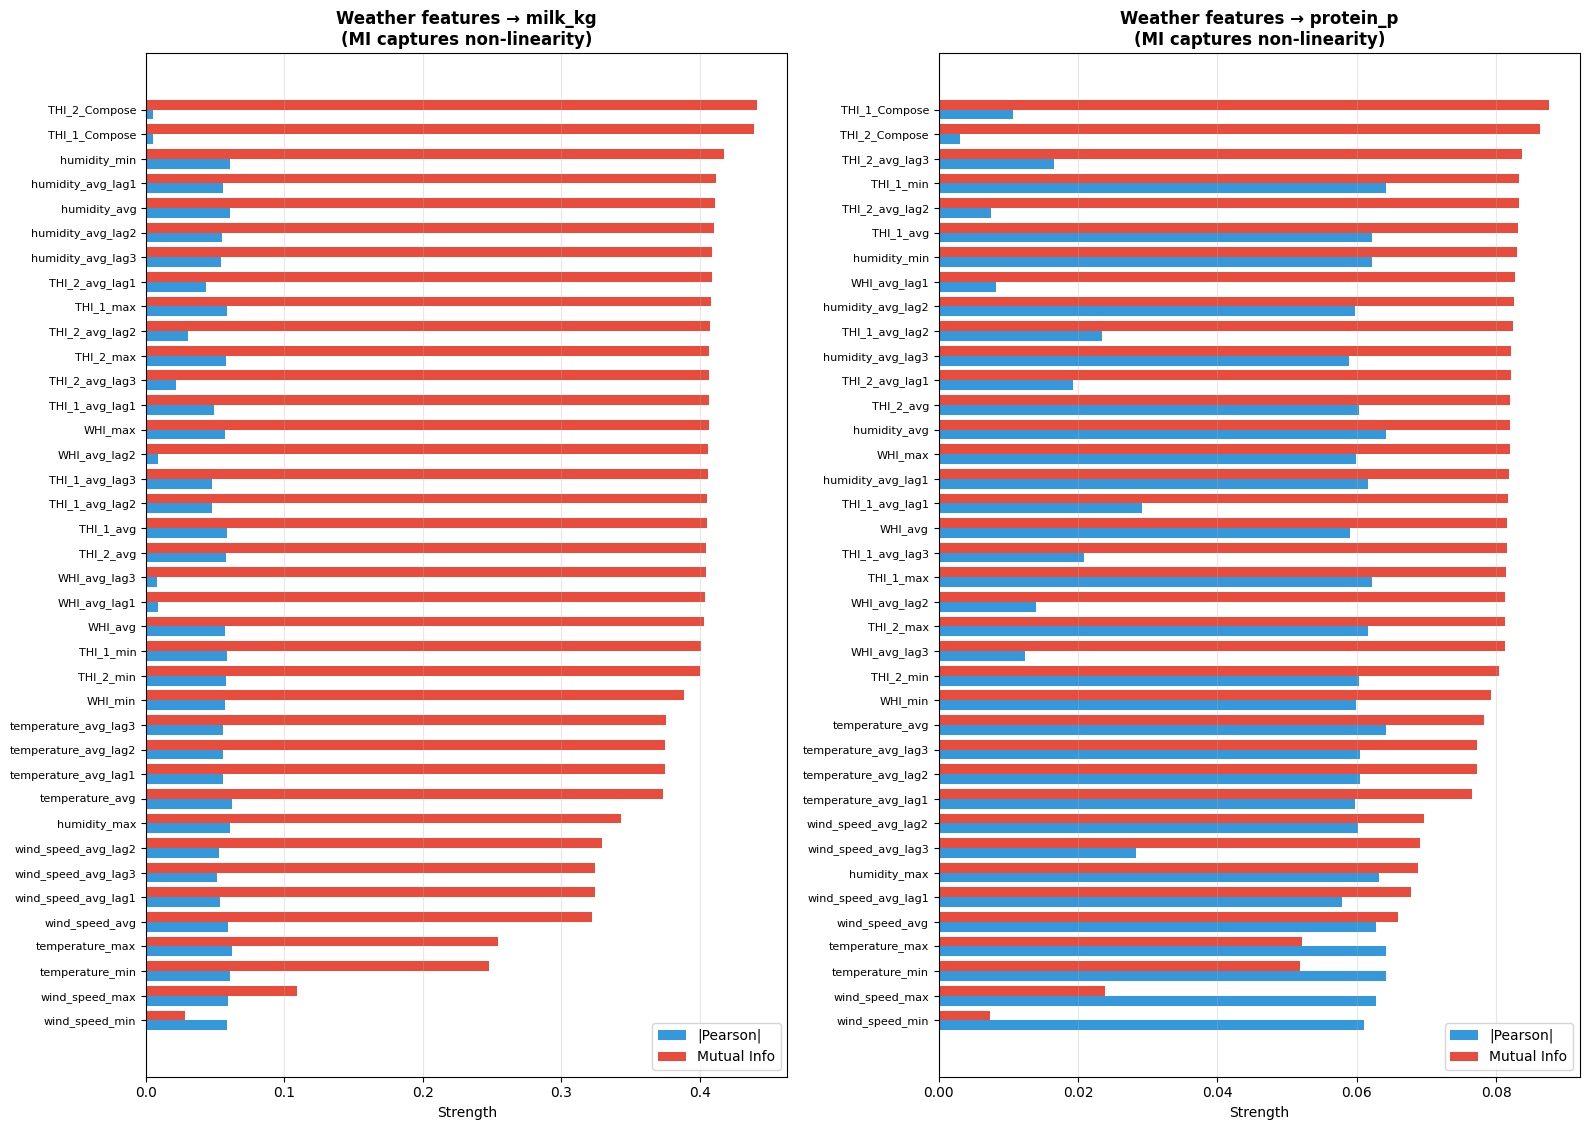

In [16]:
# Filter to weather features only (where non-linearity is most interesting)
weather_kw = ['THI', 'temperature', 'humidity', 'wind', 'WHI']
weather_features = [f for f in features if any(k in f for k in weather_kw)]

fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(weather_features)*0.3)))

for ax, target in zip(axes, ['milk_kg', 'protein_p']):
    sub = mi_df.loc[weather_features].sort_values(f'MI_{target}', ascending=True)
    y = np.arange(len(sub))
    ax.barh(y - 0.2, sub[f'Pearson_{target}'], 0.4, label='|Pearson|',     color='#3498db')
    ax.barh(y + 0.2, sub[f'MI_{target}'],      0.4, label='Mutual Info',   color='#e74c3c')
    ax.set_yticks(y); ax.set_yticklabels(sub.index, fontsize=8)
    ax.set_xlabel('Strength')
    ax.set_title(f'Weather features → {target}\n(MI captures non-linearity)', fontweight='bold')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(path + 'Final_Data/weather_mi_vs_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Binned Analysis — The Heat Stress Curve
This is the **most important plot for your thesis**. Group THI/temperature into bins
and plot the mean target per bin. If heat stress exists, you'll see a clear inflection point.


=== THI_1_Compose ===


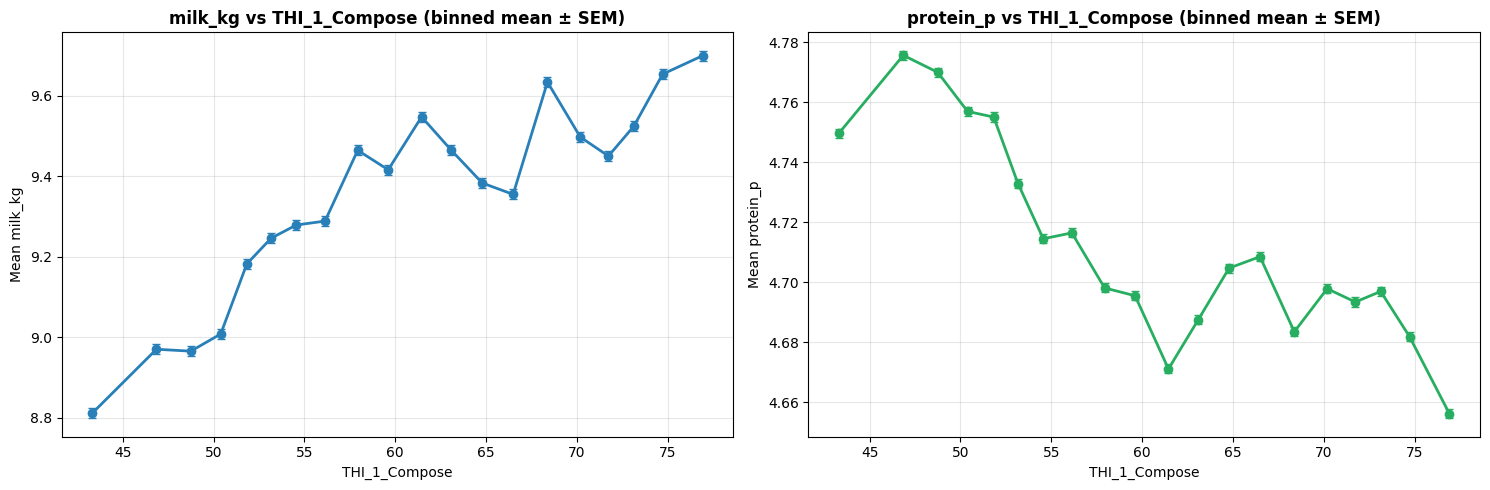


=== THI_1_avg ===


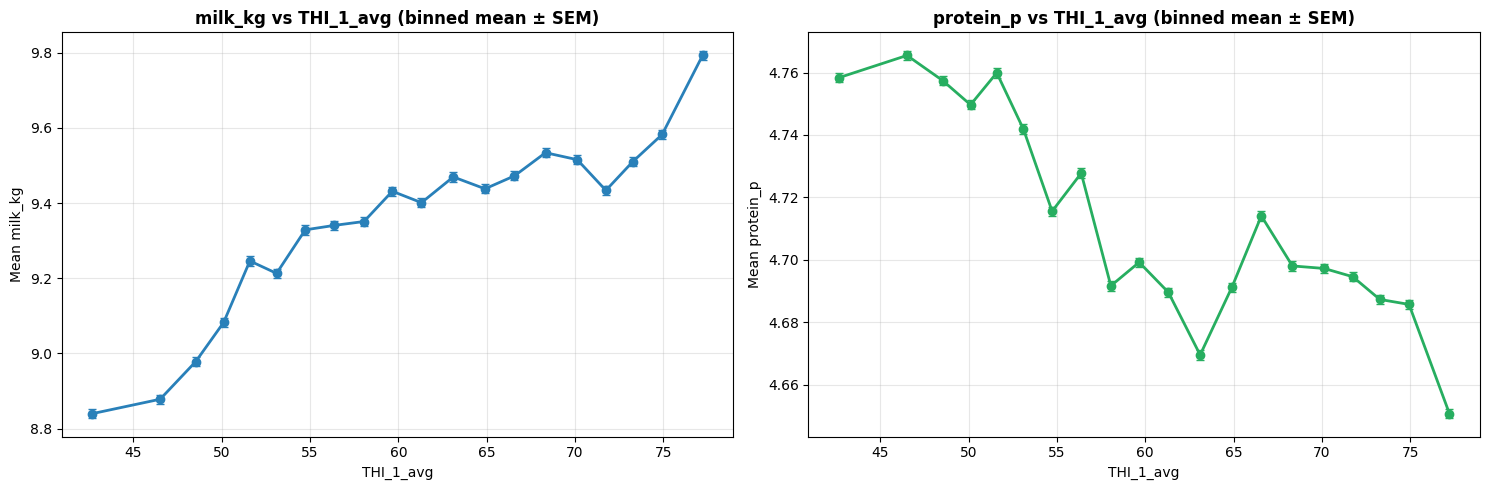


=== temperature_avg ===


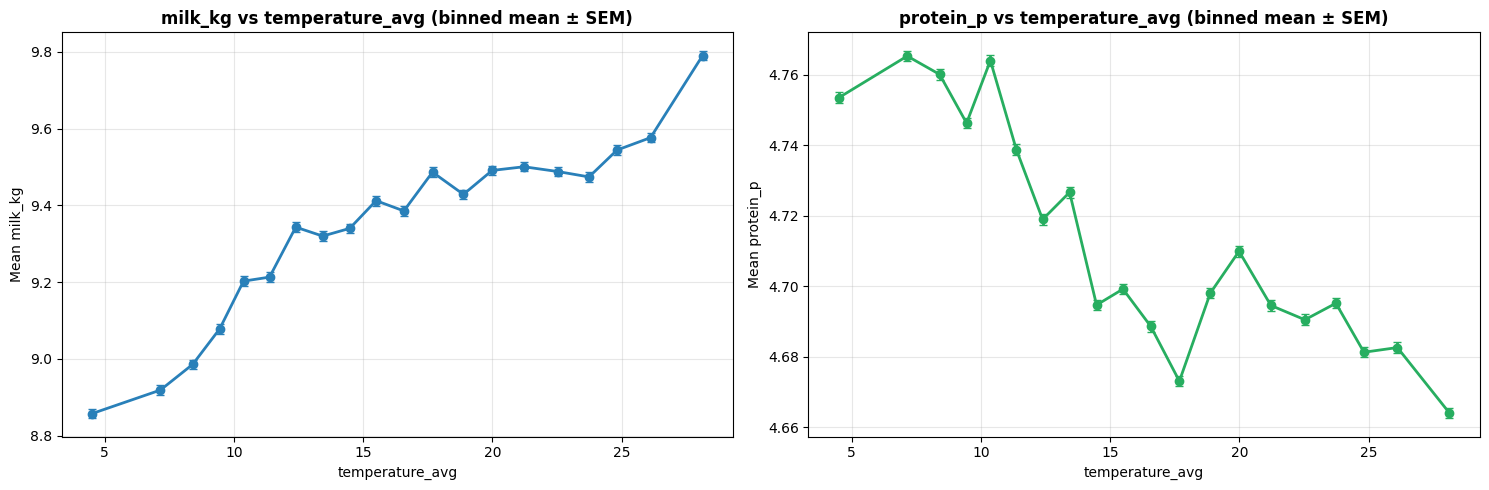


=== humidity_avg ===


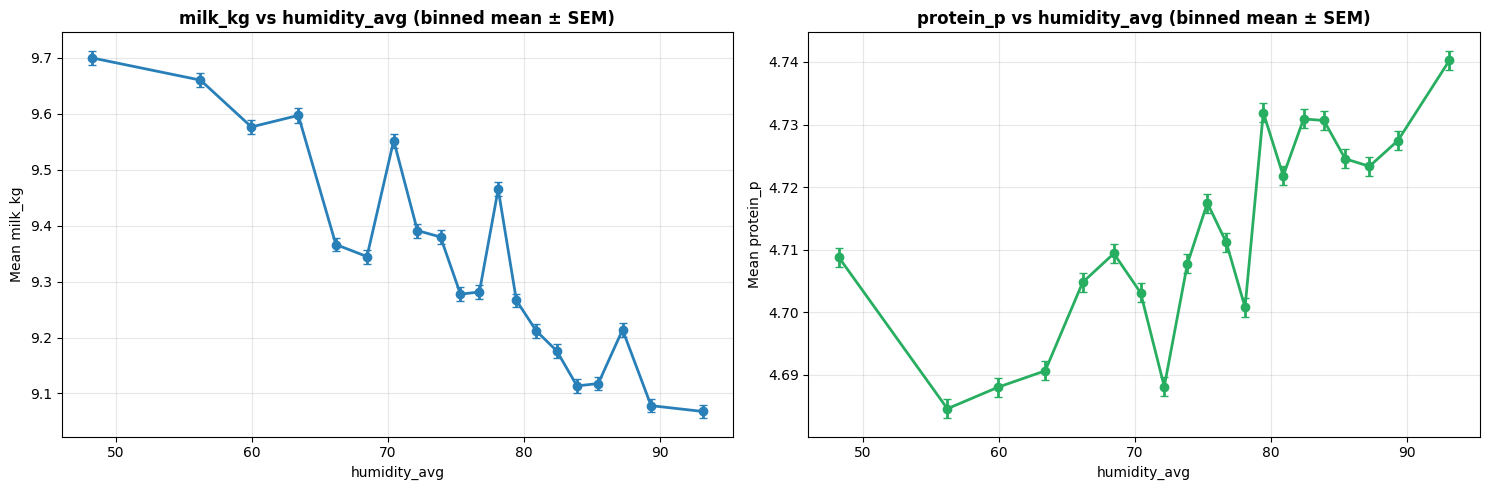

In [17]:
def plot_binned(weather_col, n_bins=20):
    sub = df[[weather_col, 'milk_kg', 'protein_p']].dropna()
    sub['bin'] = pd.qcut(sub[weather_col], q=n_bins, duplicates='drop')

    agg = sub.groupby('bin', observed=True).agg(
        milk_mean=('milk_kg', 'mean'),
        milk_sem=('milk_kg', lambda x: x.std() / np.sqrt(len(x))),
        protein_mean=('protein_p', 'mean'),
        protein_sem=('protein_p', lambda x: x.std() / np.sqrt(len(x))),
        n=('milk_kg', 'size'),
        x_mid=(weather_col, 'median'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].errorbar(agg['x_mid'], agg['milk_mean'], yerr=agg['milk_sem'],
                     fmt='o-', color='#2980b9', capsize=3, linewidth=2)
    axes[0].set_xlabel(weather_col); axes[0].set_ylabel('Mean milk_kg')
    axes[0].set_title(f'milk_kg vs {weather_col} (binned mean ± SEM)', fontweight='bold')
    axes[0].grid(alpha=0.3)

    axes[1].errorbar(agg['x_mid'], agg['protein_mean'], yerr=agg['protein_sem'],
                     fmt='o-', color='#27ae60', capsize=3, linewidth=2)
    axes[1].set_xlabel(weather_col); axes[1].set_ylabel('Mean protein_p')
    axes[1].set_title(f'protein_p vs {weather_col} (binned mean ± SEM)', fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    return agg

# Plot the four most biologically relevant weather features
for col in ['THI_1_Compose', 'THI_1_avg', 'temperature_avg', 'humidity_avg']:
    print(f"\n=== {col} ===")
    plot_binned(col, n_bins=20)

## 10. Heat Stress Threshold Test
Literature defines THI > 72 as the heat stress threshold for buffalo. Compare yield
in heat-stress days vs comfort days.

In [18]:
def threshold_compare(weather_col, threshold, label='heat stress'):
    sub = df[[weather_col, 'milk_kg', 'protein_p']].dropna()
    sub['group'] = np.where(sub[weather_col] > threshold, f'> {threshold} ({label})', f'≤ {threshold} (comfort)')

    summary = sub.groupby('group').agg(
        n=('milk_kg', 'size'),
        milk_mean=('milk_kg', 'mean'),
        milk_std=('milk_kg', 'std'),
        protein_mean=('protein_p', 'mean'),
        protein_std=('protein_p', 'std'),
    ).round(3)
    print(f"\n{weather_col}  threshold = {threshold}")
    print(summary)

    # % change
    if len(summary) == 2:
        comfort_milk = summary['milk_mean'].iloc[0]
        stress_milk  = summary['milk_mean'].iloc[1]
        print(f"  → milk_kg change:   {(stress_milk - comfort_milk)/comfort_milk*100:+.2f}%")
        comfort_pro = summary['protein_mean'].iloc[0]
        stress_pro  = summary['protein_mean'].iloc[1]
        print(f"  → protein_p change: {(stress_pro - comfort_pro)/comfort_pro*100:+.2f}%")
    return summary

# Common thresholds from buffalo heat-stress literature
for col, thresh in [('THI_1_avg', 72), ('THI_1_avg', 75), ('THI_1_Compose', 72), ('temperature_avg', 25)]:
    threshold_compare(col, thresh)


THI_1_avg  threshold = 72
                          n  milk_mean  milk_std  protein_mean  protein_std
group                                                                      
> 72 (heat stress)   274145      9.604     3.521         4.676        0.430
≤ 72 (comfort)      1372664      9.290     3.574         4.719        0.435
  → milk_kg change:   -3.27%
  → protein_p change: +0.92%

THI_1_avg  threshold = 75
                          n  milk_mean  milk_std  protein_mean  protein_std
group                                                                      
> 75 (heat stress)   119888      9.728     3.567         4.659        0.430
≤ 75 (comfort)      1526921      9.312     3.566         4.716        0.435
  → milk_kg change:   -4.28%
  → protein_p change: +1.22%

THI_1_Compose  threshold = 72
                          n  milk_mean  milk_std  protein_mean  protein_std
group                                                                      
> 72 (heat stress)   272037      9.603 

## 11. Conditional Correlation (above heat-stress threshold)
If a relationship exists only above THI 72, computing Pearson on the full dataset
dilutes it to near-zero. Recompute on stress days only.

In [19]:
thresh = 72
hot = df[df['THI_1_avg'] > thresh][features + targets].dropna()
cool = df[df['THI_1_avg'] <= thresh][features + targets].dropna()

print(f"Hot days (THI > {thresh}):   {len(hot):,} records")
print(f"Cool days (THI ≤ {thresh}):  {len(cool):,} records")

weather_kw = ['THI', 'temperature', 'humidity', 'wind', 'WHI']
weather_features = [f for f in features if any(k in f for k in weather_kw)]

cond = pd.DataFrame({
    'all_milk':  pearson['milk_kg'].loc[weather_features],
    'hot_milk':  hot[weather_features + ['milk_kg']].corr()['milk_kg'].drop('milk_kg'),
    'cool_milk': cool[weather_features + ['milk_kg']].corr()['milk_kg'].drop('milk_kg'),
    'all_protein':  pearson['protein_p'].loc[weather_features],
    'hot_protein':  hot[weather_features + ['protein_p']].corr()['protein_p'].drop('protein_p'),
    'cool_protein': cool[weather_features + ['protein_p']].corr()['protein_p'].drop('protein_p'),
}).round(3)
cond = cond.reindex(cond['hot_milk'].abs().sort_values(ascending=False).index)
print("\nCorrelation of weather features under each regime:")
print(cond)

Hot days (THI > 72):   274,145 records
Cool days (THI ≤ 72):  1,372,664 records

Correlation of weather features under each regime:
                      all_milk  hot_milk  cool_milk  all_protein  hot_protein  \
WHI_min                  0.053     0.047      0.044       -0.058       -0.027   
humidity_max            -0.031    -0.045     -0.019        0.008       -0.013   
temperature_min          0.054     0.044      0.044       -0.059       -0.035   
THI_1_min                0.058     0.043      0.050       -0.060       -0.039   
THI_2_min                0.057     0.043      0.050       -0.060       -0.039   
WHI_avg                  0.058     0.027      0.052       -0.064       -0.013   
temperature_avg          0.061     0.026      0.056       -0.063       -0.013   
humidity_avg_lag1       -0.048    -0.026     -0.041        0.021       -0.024   
humidity_avg_lag2       -0.043    -0.025     -0.035        0.019       -0.019   
THI_2_max                0.059    -0.025      0.057       

## 12. Stratified Analysis — DIM × Heat Stress
Heat stress effect varies by lactation stage. Early-lactation cows are more affected.

Mean milk_kg by THI × DIM stage:
DIM_stage            Early (0-60)  Peak (60-150)  Mid (150-305)  \
THI_bin                                                           
<65 (cold)                  11.68          10.40           7.27   
65-72 (comfort)             11.59          10.57           7.60   
72-78 (mild stress)         11.67          10.67           7.87   
78-85 (severe)              11.48          10.43           7.75   

DIM_stage            Late (305-365)  
THI_bin                              
<65 (cold)                     5.77  
65-72 (comfort)                5.69  
72-78 (mild stress)            5.67  
78-85 (severe)                 5.63  


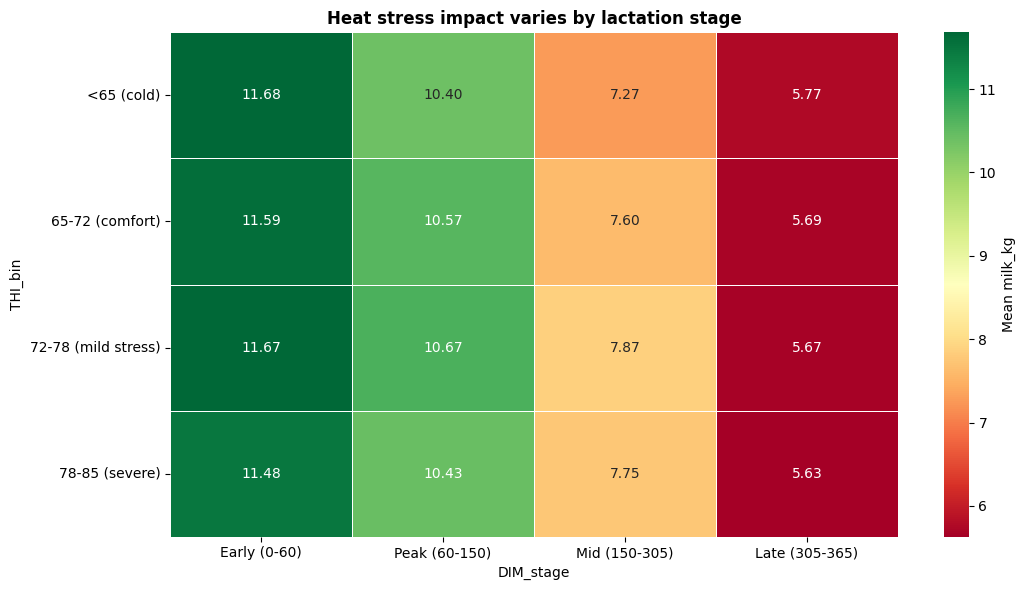

In [20]:
sub = df[['THI_1_avg', 'DIM', 'milk_kg']].dropna().copy()
sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])
sub['THI_bin'] = pd.cut(sub['THI_1_avg'], bins=[-np.inf, 65, 72, 78, 85, np.inf],
                        labels=['<65 (cold)', '65-72 (comfort)', '72-78 (mild stress)', '78-85 (severe)', '>85 (extreme)'])

pivot = sub.pivot_table(index='THI_bin', columns='DIM_stage', values='milk_kg',
                        aggfunc='mean', observed=True).round(2)
print("Mean milk_kg by THI × DIM stage:")
print(pivot)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            cbar_kws={'label': 'Mean milk_kg'}, linewidths=0.5)
ax.set_title('Heat stress impact varies by lactation stage', fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'Final_Data/heat_x_dim_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 💧 Section 13 — Deep Dive into Humidity

The binned analysis showed humidity is the **only weather variable** with a clean monotonic
relationship to milk yield (~−6.5% drop from 50% → 90% humidity). Let's drill in:

1. Does the effect hold when we control for DIM?
2. What's the % milk loss per 10% humidity increase?
3. Does humidity matter more when combined with high temperature?
4. Does humidity show the same effect on protein?

## 13.1 Humidity × DIM Heatmap

Mean milk_kg by Humidity × DIM stage:
DIM_stage          Early (0-60)  Peak (60-150)  Mid (150-305)  Late (305-365)
Hum_bin                                                                      
<60% (dry)                11.89          10.76           7.61            5.80
60-70%                    11.76          10.62           7.53            5.69
70-80%                    11.61          10.46           7.45            5.75
80-90%                    11.58          10.33           7.30            5.72
>90% (very humid)         11.45          10.23           7.40            5.80

Mean protein_p by Humidity × DIM stage:
DIM_stage          Early (0-60)  Peak (60-150)  Mid (150-305)  Late (305-365)
Hum_bin                                                                      
<60% (dry)                4.563          4.550          4.879           5.087
60-70%                    4.572          4.557          4.870           5.023
70-80%                    4.587          4.570          4.874  

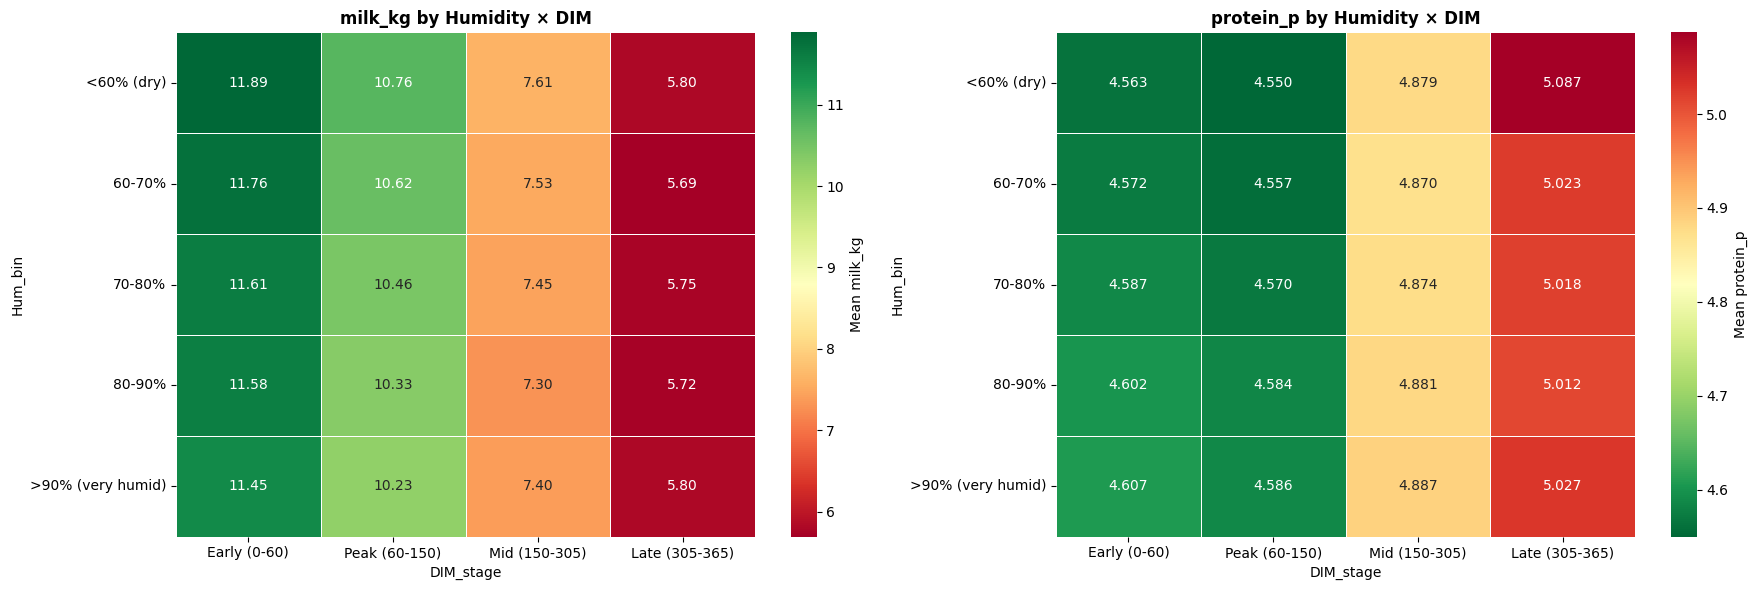

In [21]:
sub = df[['humidity_avg', 'DIM', 'milk_kg', 'protein_p']].dropna().copy()
sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])
sub['Hum_bin'] = pd.cut(sub['humidity_avg'],
                        bins=[0, 60, 70, 80, 90, 100],
                        labels=['<60% (dry)', '60-70%', '70-80%', '80-90%', '>90% (very humid)'])

pivot_milk = sub.pivot_table(index='Hum_bin', columns='DIM_stage', values='milk_kg',
                             aggfunc='mean', observed=True).round(2)
pivot_pro  = sub.pivot_table(index='Hum_bin', columns='DIM_stage', values='protein_p',
                             aggfunc='mean', observed=True).round(3)
n_pivot    = sub.pivot_table(index='Hum_bin', columns='DIM_stage', values='milk_kg',
                             aggfunc='size', observed=True)

print('Mean milk_kg by Humidity × DIM stage:')
print(pivot_milk)
print('\nMean protein_p by Humidity × DIM stage:')
print(pivot_pro)
print('\nSample size per cell:')
print(n_pivot)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(pivot_milk, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Mean milk_kg'})
axes[0].set_title('milk_kg by Humidity × DIM', fontweight='bold')

sns.heatmap(pivot_pro, annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Mean protein_p'})
axes[1].set_title('protein_p by Humidity × DIM', fontweight='bold')

plt.tight_layout()
plt.savefig(path + 'Final_Data/humidity_x_dim_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13.2 % Milk Loss per +10% Humidity (within each DIM stage)

Mean milk_kg per humidity bin × DIM stage:
Hum_10bin       40-50  50-60  60-70  70-80  80-90  90-100
DIM_stage                                                
Early (0-60)    12.11  11.81  11.76  11.61  11.58   11.45
Peak (60-150)   10.99  10.69  10.62  10.46  10.33   10.23
Mid (150-305)    7.86   7.53   7.53   7.45   7.30    7.40
Late (305-365)   6.20   5.70   5.69   5.75   5.72    5.80

=== Total milk_kg change per DIM stage (driest → most humid) ===
  Early (0-60):  12.11 → 11.45  (-5.49%)
  Peak (60-150):  10.99 → 10.23  (-6.87%)
  Mid (150-305):  7.86 → 7.40  (-5.91%)
  Late (305-365):  6.20 → 5.80  (-6.35%)


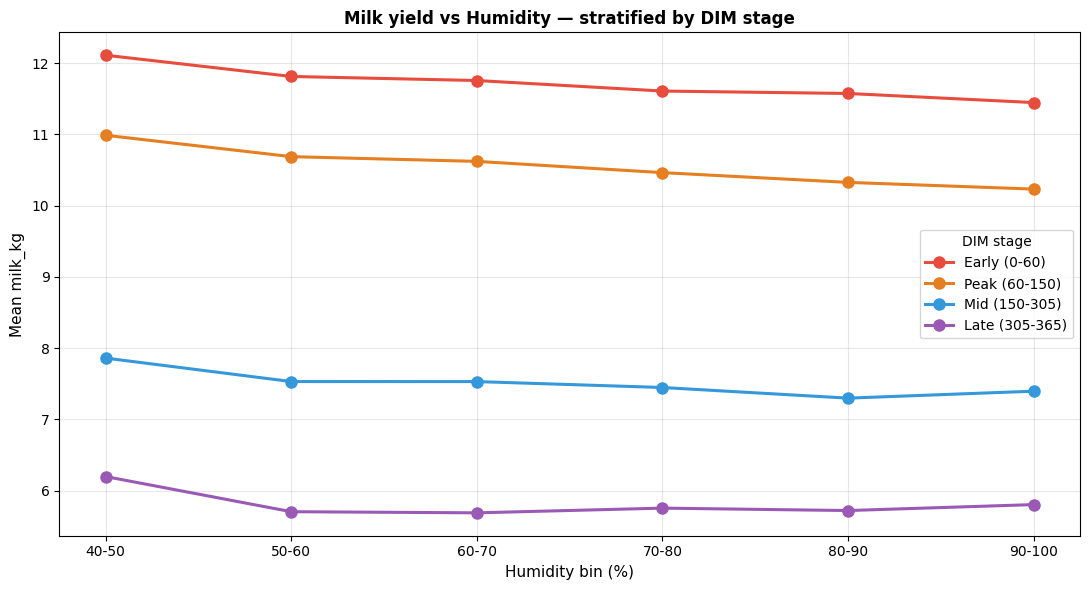

In [22]:
# Compute mean milk per 10% humidity bin within each DIM stage
sub = df[['humidity_avg', 'DIM', 'milk_kg']].dropna().copy()
sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])
sub['Hum_10bin'] = pd.cut(sub['humidity_avg'],
                          bins=np.arange(40, 101, 10),
                          labels=['40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])

trend = sub.groupby(['DIM_stage', 'Hum_10bin'], observed=True)['milk_kg'].mean().unstack()
print('Mean milk_kg per humidity bin × DIM stage:')
print(trend.round(2))

# % change from driest to most humid bin
print('\n=== Total milk_kg change per DIM stage (driest → most humid) ===')
for stage in trend.index:
    row = trend.loc[stage].dropna()
    if len(row) >= 2:
        pct = (row.iloc[-1] - row.iloc[0]) / row.iloc[0] * 100
        print(f'  {stage}:  {row.iloc[0]:.2f} → {row.iloc[-1]:.2f}  ({pct:+.2f}%)')

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6']
for color, stage in zip(colors, trend.index):
    row = trend.loc[stage]
    ax.plot(row.index.astype(str), row.values, 'o-', linewidth=2.2, markersize=8,
            label=str(stage), color=color)
ax.set_xlabel('Humidity bin (%)', fontsize=11)
ax.set_ylabel('Mean milk_kg', fontsize=11)
ax.set_title('Milk yield vs Humidity — stratified by DIM stage', fontweight='bold')
ax.legend(title='DIM stage')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(path + 'Final_Data/humidity_dim_lines.png', dpi=150, bbox_inches='tight')
plt.show()

## 13.3 Humidity × Temperature Interaction
Is humidity worse when it's also hot? (Classic THI logic, but visualised directly.)

Mean milk_kg by Humidity × Temperature:
Temp_bin  <10°C (cold)  10-18°C (cool)  18-24°C (mild)  24-28°C (warm)  \
Hum_bin                                                                  
<60%              9.29            9.72            9.79            9.55   
60-70%            9.21            9.66            9.47            9.55   
70-80%            8.91            9.40            9.47            9.69   
80-90%            8.78            9.23            9.34            9.66   
>90%              8.96            9.02            9.75             NaN   

Temp_bin  >28°C (hot)  
Hum_bin                
<60%             9.85  
60-70%           9.37  
70-80%           8.82  
80-90%            NaN  
>90%              NaN  

Sample size per cell:
Temp_bin  <10°C (cold)  10-18°C (cool)  18-24°C (mild)  24-28°C (warm)  \
Hum_bin                                                                  
<60%           29372.0         28166.0         49116.0         69667.0   
60-70%         63146.0      

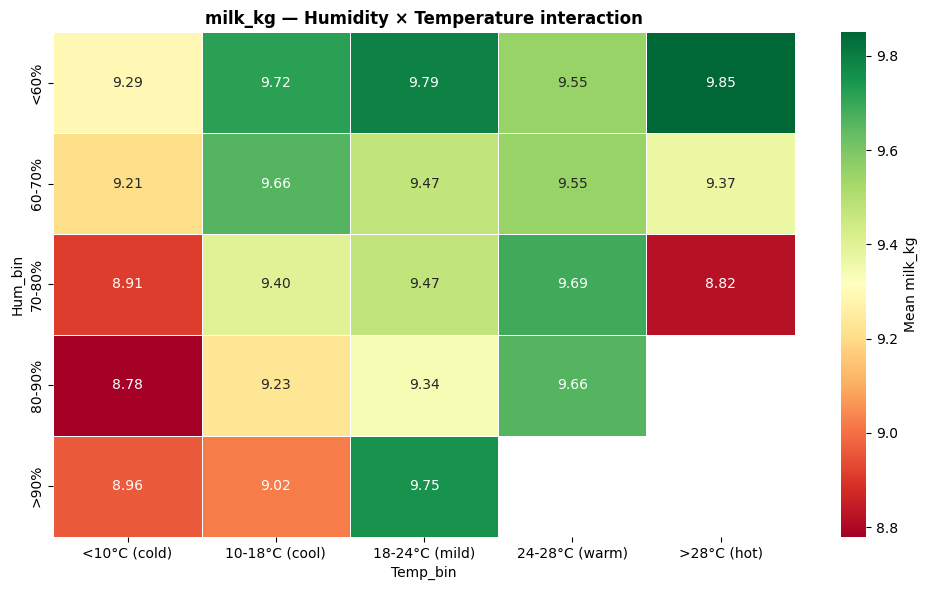

In [23]:
sub = df[['humidity_avg', 'temperature_avg', 'milk_kg']].dropna().copy()
sub['Hum_bin'] = pd.cut(sub['humidity_avg'], bins=[0, 60, 70, 80, 90, 100],
                        labels=['<60%', '60-70%', '70-80%', '80-90%', '>90%'])
sub['Temp_bin'] = pd.cut(sub['temperature_avg'],
                         bins=[-100, 10, 18, 24, 28, 100],
                         labels=['<10°C (cold)', '10-18°C (cool)', '18-24°C (mild)',
                                 '24-28°C (warm)', '>28°C (hot)'])

pivot = sub.pivot_table(index='Hum_bin', columns='Temp_bin', values='milk_kg',
                        aggfunc='mean', observed=True).round(2)
n     = sub.pivot_table(index='Hum_bin', columns='Temp_bin', values='milk_kg',
                        aggfunc='size', observed=True)

print('Mean milk_kg by Humidity × Temperature:')
print(pivot)
print('\nSample size per cell:')
print(n)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Mean milk_kg'})
ax.set_title('milk_kg — Humidity × Temperature interaction', fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'Final_Data/humidity_x_temp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 13.4 Humidity Threshold Tests
At which humidity level does milk yield clearly drop?

In [24]:
def humidity_threshold(df, threshold):
    sub = df[['humidity_avg', 'DIM', 'milk_kg', 'protein_p']].dropna().copy()
    sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                              labels=['Early', 'Peak', 'Mid', 'Late'])
    sub['humid_group'] = np.where(sub['humidity_avg'] > threshold, 'HIGH', 'LOW')

    print(f'\n=== Threshold: humidity > {threshold}% ===')
    for stage in ['Early', 'Peak', 'Mid', 'Late']:
        s = sub[sub['DIM_stage'] == stage]
        lo = s[s['humid_group'] == 'LOW']['milk_kg'].mean()
        hi = s[s['humid_group'] == 'HIGH']['milk_kg'].mean()
        if pd.notna(lo) and pd.notna(hi):
            pct = (hi - lo) / lo * 100
            print(f'  {stage:6s} DIM:  LOW={lo:.2f}  HIGH={hi:.2f}  Δ={pct:+.2f}%')

for thr in [70, 75, 80, 85, 90]:
    humidity_threshold(df, thr)


=== Threshold: humidity > 70% ===
  Early  DIM:  LOW=11.81  HIGH=11.58  Δ=-1.95%
  Peak   DIM:  LOW=10.68  HIGH=10.39  Δ=-2.74%
  Mid    DIM:  LOW=7.56  HIGH=7.38  Δ=-2.43%
  Late   DIM:  LOW=5.73  HIGH=5.75  Δ=+0.24%

=== Threshold: humidity > 75% ===
  Early  DIM:  LOW=11.77  HIGH=11.55  Δ=-1.83%
  Peak   DIM:  LOW=10.61  HIGH=10.36  Δ=-2.36%
  Mid    DIM:  LOW=7.53  HIGH=7.35  Δ=-2.42%
  Late   DIM:  LOW=5.74  HIGH=5.74  Δ=+0.00%

=== Threshold: humidity > 80% ===
  Early  DIM:  LOW=11.71  HIGH=11.55  Δ=-1.34%
  Peak   DIM:  LOW=10.57  HIGH=10.31  Δ=-2.43%
  Mid    DIM:  LOW=7.50  HIGH=7.32  Δ=-2.49%
  Late   DIM:  LOW=5.74  HIGH=5.74  Δ=-0.09%

=== Threshold: humidity > 85% ===
  Early  DIM:  LOW=11.68  HIGH=11.56  Δ=-1.04%
  Peak   DIM:  LOW=10.52  HIGH=10.28  Δ=-2.31%
  Mid    DIM:  LOW=7.46  HIGH=7.32  Δ=-1.87%
  Late   DIM:  LOW=5.74  HIGH=5.76  Δ=+0.44%

=== Threshold: humidity > 90% ===
  Early  DIM:  LOW=11.67  HIGH=11.45  Δ=-1.91%
  Peak   DIM:  LOW=10.49  HIGH=10.23  Δ=-2

## 13.5 Quantify the Slope — "Milk Loss per +1% Humidity"
Fit a simple linear regression within each DIM stage to get a single biological number.

In [25]:
from scipy.stats import linregress

sub = df[['humidity_avg', 'DIM', 'milk_kg', 'protein_p']].dropna().copy()
sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])

results = []
for stage in sub['DIM_stage'].cat.categories:
    s = sub[sub['DIM_stage'] == stage]
    lr_milk = linregress(s['humidity_avg'], s['milk_kg'])
    lr_pro  = linregress(s['humidity_avg'], s['protein_p'])
    results.append({
        'DIM_stage':       stage,
        'n':               len(s),
        'milk_slope':      lr_milk.slope,
        'milk_slope_per10':lr_milk.slope * 10,
        'milk_r':          lr_milk.rvalue,
        'milk_p':          lr_milk.pvalue,
        'protein_slope':   lr_pro.slope,
        'protein_slope_per10': lr_pro.slope * 10,
        'protein_r':       lr_pro.rvalue,
        'protein_p':       lr_pro.pvalue,
    })

results_df = pd.DataFrame(results)
print('Slope of milk_kg / protein_p vs humidity within each DIM stage:')
print(results_df.round(4).to_string(index=False))

print('\nInterpretation:')
for r in results:
    print(f"  {r['DIM_stage']}:  every +10% humidity → "
          f"{r['milk_slope_per10']:+.3f} kg milk, "
          f"{r['protein_slope_per10']:+.4f} %% protein  "
          f"(r_milk={r['milk_r']:+.3f})")

Slope of milk_kg / protein_p vs humidity within each DIM stage:
     DIM_stage      n  milk_slope  milk_slope_per10  milk_r  milk_p  protein_slope  protein_slope_per10  protein_r  protein_p
  Early (0-60) 347377     -0.0109           -0.1089 -0.0367  0.0000         0.0013               0.0132     0.0361        0.0
 Peak (60-150) 581906     -0.0143           -0.1432 -0.0524  0.0000         0.0011               0.0109     0.0335        0.0
 Mid (150-305) 659844     -0.0093           -0.0928 -0.0398  0.0000         0.0003               0.0027     0.0077        0.0
Late (305-365)  57682     -0.0005           -0.0052 -0.0025  0.5497        -0.0015              -0.0149    -0.0381        0.0

Interpretation:
  Early (0-60):  every +10% humidity → -0.109 kg milk, +0.0132 %% protein  (r_milk=-0.037)
  Peak (60-150):  every +10% humidity → -0.143 kg milk, +0.0109 %% protein  (r_milk=-0.052)
  Mid (150-305):  every +10% humidity → -0.093 kg milk, +0.0027 %% protein  (r_milk=-0.040)
  Late (305-36

---
# 🔬 Section 14 — Within-Animal Fixed-Effect Analysis

**Goal:** Confirm the humidity → milk effect is **causal within the same animal**,
not driven by between-animal selection (different cows, farms, genetics).

**Method:**
1. For each animal, compute her own mean humidity and own mean milk.
2. Compute each record's *deviation* from that animal's own baseline.
3. Correlate the deviations.

If, **for the same cow**, her milk drops on her humid days (compared to her own dry days), then the relationship is real and not a between-animal artefact.

In [26]:
sub = df[['Animal_ID', 'humidity_avg', 'milk_kg', 'protein_p', 'DIM']].dropna().copy()

# Animal-level means (the "between" component)
animal_means = sub.groupby('Animal_ID').agg(
    hum_mean=('humidity_avg', 'mean'),
    milk_mean=('milk_kg', 'mean'),
    pro_mean=('protein_p', 'mean'),
    n=('milk_kg', 'size')
)

# Keep only animals with >=5 records (so the within-animal mean is meaningful)
animal_means = animal_means[animal_means['n'] >= 5]
sub = sub[sub['Animal_ID'].isin(animal_means.index)]

# Demean (subtract each animal's own mean)
sub = sub.merge(animal_means, left_on='Animal_ID', right_index=True)
sub['hum_dev']  = sub['humidity_avg'] - sub['hum_mean']
sub['milk_dev'] = sub['milk_kg']      - sub['milk_mean']
sub['pro_dev']  = sub['protein_p']    - sub['pro_mean']

print(f"Animals with >=5 records:  {animal_means.shape[0]:,}")
print(f"Records used:              {len(sub):,}")

# Within-animal Pearson correlation
within_milk = sub[['hum_dev', 'milk_dev']].corr().iloc[0, 1]
within_pro  = sub[['hum_dev', 'pro_dev']].corr().iloc[0, 1]

# Between-animal Pearson (animal means)
between_milk = animal_means[['hum_mean', 'milk_mean']].corr().iloc[0, 1]
between_pro  = animal_means[['hum_mean', 'pro_mean']].corr().iloc[0, 1]

# Pooled (naive)
pooled_milk = sub[['humidity_avg', 'milk_kg']].corr().iloc[0, 1]
pooled_pro  = sub[['humidity_avg', 'protein_p']].corr().iloc[0, 1]

results = pd.DataFrame({
    'humidity → milk_kg':   [pooled_milk, between_milk, within_milk],
    'humidity → protein_p': [pooled_pro,  between_pro,  within_pro],
}, index=['Pooled (naive)', 'Between animals', 'Within animal (fixed effect)']).round(4)

print('\nCorrelation decomposition:')
print(results)
print()
print('Interpretation:')
print('  • Pooled: the raw correlation everyone reports')
print('  • Between: variation in animal-level *averages* (driven by farm/genetics)')
print('  • Within: variation *for the same animal* across her own records')
print('    ↑ this is the causal humidity effect, after removing every between-animal confounder')

Animals with >=5 records:  84,176
Records used:              1,621,925

Correlation decomposition:
                              humidity → milk_kg  humidity → protein_p
Pooled (naive)                           -0.0513                0.0283
Between animals                          -0.1133                0.0187
Within animal (fixed effect)             -0.0347                0.0323

Interpretation:
  • Pooled: the raw correlation everyone reports
  • Between: variation in animal-level *averages* (driven by farm/genetics)
  • Within: variation *for the same animal* across her own records
    ↑ this is the causal humidity effect, after removing every between-animal confounder


### 14.1 Within-animal slope per DIM stage

In [27]:
from scipy.stats import linregress

sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])

print('Within-animal slope of milk_kg vs humidity (after demeaning):')
print(f"{'DIM stage':<20}{'n':>10}{'slope_per10%':>16}{'r_within':>12}{'p':>14}")
print('-' * 72)
for stage in sub['DIM_stage'].cat.categories:
    s = sub[sub['DIM_stage'] == stage].dropna(subset=['hum_dev', 'milk_dev'])
    lr = linregress(s['hum_dev'], s['milk_dev'])
    print(f"{str(stage):<20}{len(s):>10,}{lr.slope*10:>+16.4f}{lr.rvalue:>+12.4f}{lr.pvalue:>14.2e}")

print('\n→ Compare these slopes to Section 13.5 (which mixed between+within variation)')

Within-animal slope of milk_kg vs humidity (after demeaning):
DIM stage                    n    slope_per10%    r_within             p
------------------------------------------------------------------------
Early (0-60)           339,082         -0.0383     -0.0153      4.78e-19
Peak (60-150)          569,007         -0.0371     -0.0165      1.60e-35
Mid (150-305)          656,339         -0.0722     -0.0349     1.01e-175
Late (305-365)          57,497         -0.0167     -0.0083      4.66e-02

→ Compare these slopes to Section 13.5 (which mixed between+within variation)


### 14.2 Visual proof — scatter of demeaned values

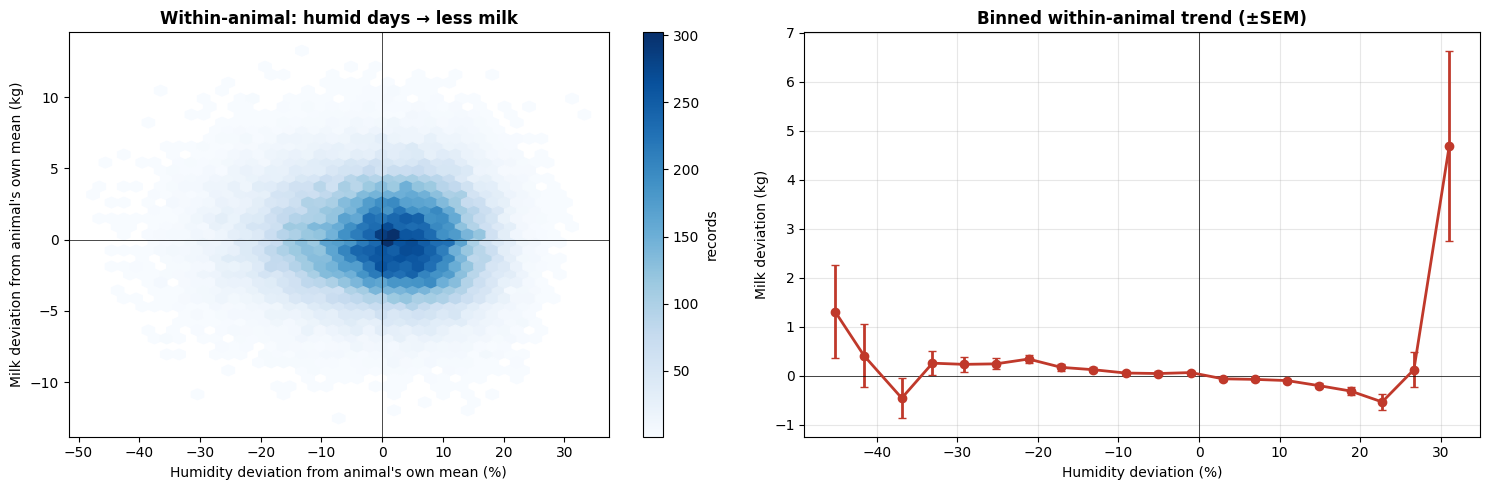

In [28]:
# Subsample (with so many points a scatter is unreadable)
sample = sub.sample(min(50_000, len(sub)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hex-bin (better than scatter for 50k points)
hb = axes[0].hexbin(sample['hum_dev'], sample['milk_dev'],
                    gridsize=40, cmap='Blues', mincnt=1)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axvline(0, color='black', lw=0.5)
axes[0].set_xlabel('Humidity deviation from animal\'s own mean (%)')
axes[0].set_ylabel('Milk deviation from animal\'s own mean (kg)')
axes[0].set_title('Within-animal: humid days → less milk', fontweight='bold')
plt.colorbar(hb, ax=axes[0], label='records')

# Binned trend (mean milk deviation per humidity deviation bin)
sample['hum_dev_bin'] = pd.cut(sample['hum_dev'], bins=20)
trend = sample.groupby('hum_dev_bin', observed=True).agg(
    x=('hum_dev', 'mean'),
    y_mean=('milk_dev', 'mean'),
    y_sem=('milk_dev', lambda x: x.std()/np.sqrt(len(x))),
)
axes[1].errorbar(trend['x'], trend['y_mean'], yerr=trend['y_sem'],
                 fmt='o-', color='#c0392b', capsize=3, linewidth=2)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_xlabel('Humidity deviation (%)')
axes[1].set_ylabel('Milk deviation (kg)')
axes[1].set_title('Binned within-animal trend (±SEM)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(path + 'Final_Data/within_animal_humidity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🏠 Section 15 — Farm-Level Stability

**Goal:** Verify the humidity effect is **not driven by a handful of farms**.

**Method:**
1. For each farm with ≥1000 records, fit a separate slope of `milk_kg ~ humidity_avg`.
2. Plot the distribution of slopes.
3. Report: what fraction of farms show a negative slope?

In [29]:
from scipy.stats import linregress

sub = df[['Farm_Code', 'humidity_avg', 'milk_kg', 'DIM']].dropna().copy()

farm_results = []
for farm, g in sub.groupby('Farm_Code'):
    if len(g) < 1000:
        continue
    lr = linregress(g['humidity_avg'], g['milk_kg'])
    farm_results.append({
        'Farm_Code':       farm,
        'n':               len(g),
        'slope_per10':     lr.slope * 10,
        'r':               lr.rvalue,
        'p':               lr.pvalue,
        'mean_humidity':   g['humidity_avg'].mean(),
        'mean_milk':       g['milk_kg'].mean(),
    })

farm_df = pd.DataFrame(farm_results)
print(f"Farms with >=1000 records: {len(farm_df)}")
print(f"Median slope per +10% humidity:   {farm_df['slope_per10'].median():+.4f} kg")
print(f"Mean slope per +10% humidity:     {farm_df['slope_per10'].mean():+.4f} kg")
print(f"% of farms with negative slope:   {(farm_df['slope_per10'] < 0).mean()*100:.1f}%")
print(f"% of farms with significant neg.: {((farm_df['slope_per10'] < 0) & (farm_df['p'] < 0.05)).mean()*100:.1f}%")
print(f"% of farms with significant pos.: {((farm_df['slope_per10'] > 0) & (farm_df['p'] < 0.05)).mean()*100:.1f}%")
print()
print('Distribution of slopes:')
print(farm_df['slope_per10'].describe().round(4))

Farms with >=1000 records: 239
Median slope per +10% humidity:   -0.0838 kg
Mean slope per +10% humidity:     -0.0847 kg
% of farms with negative slope:   64.9%
% of farms with significant neg.: 49.0%
% of farms with significant pos.: 20.1%

Distribution of slopes:
count    239.0000
mean      -0.0847
std        0.2073
min       -0.5820
25%       -0.2223
50%       -0.0838
75%        0.0583
max        0.4630
Name: slope_per10, dtype: float64


### 15.1 Distribution of farm slopes

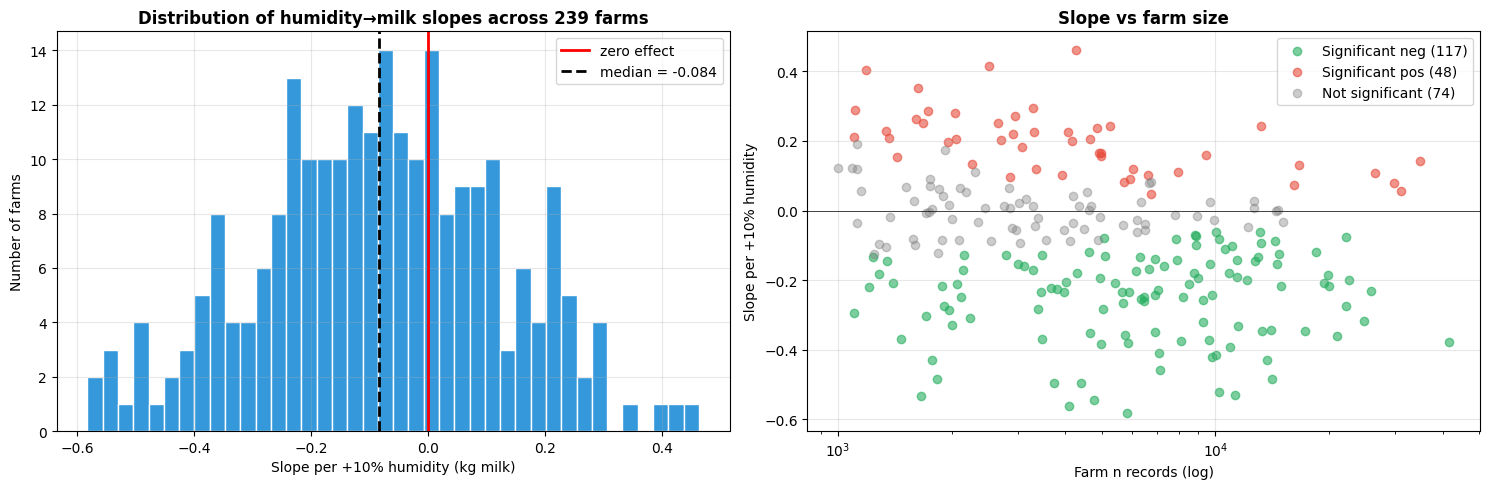

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(farm_df['slope_per10'], bins=40, color='#3498db', edgecolor='white')
axes[0].axvline(0, color='red', linewidth=2, label='zero effect')
axes[0].axvline(farm_df['slope_per10'].median(), color='black', linewidth=2,
                linestyle='--', label=f"median = {farm_df['slope_per10'].median():.3f}")
axes[0].set_xlabel('Slope per +10% humidity (kg milk)')
axes[0].set_ylabel('Number of farms')
axes[0].set_title(f'Distribution of humidity→milk slopes across {len(farm_df)} farms',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Slope vs n_records (does effect depend on farm size?)
sig_neg = (farm_df['slope_per10'] < 0) & (farm_df['p'] < 0.05)
sig_pos = (farm_df['slope_per10'] > 0) & (farm_df['p'] < 0.05)
ns      = ~(sig_neg | sig_pos)
axes[1].scatter(farm_df.loc[sig_neg, 'n'], farm_df.loc[sig_neg, 'slope_per10'],
                color='#27ae60', alpha=0.6, label=f'Significant neg ({sig_neg.sum()})')
axes[1].scatter(farm_df.loc[sig_pos, 'n'], farm_df.loc[sig_pos, 'slope_per10'],
                color='#e74c3c', alpha=0.6, label=f'Significant pos ({sig_pos.sum()})')
axes[1].scatter(farm_df.loc[ns, 'n'], farm_df.loc[ns, 'slope_per10'],
                color='gray', alpha=0.4, label=f'Not significant ({ns.sum()})')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Farm n records (log)')
axes[1].set_ylabel('Slope per +10% humidity')
axes[1].set_title('Slope vs farm size', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(path + 'Final_Data/farm_slope_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# ⏱️ Section 16 — Temporal Lag Structure of the Humidity Effect

**Goal:** Find which **time lag** of humidity best predicts milk yield.
This is directly informative for your **hierarchical time-series forecasting** model:
do you need today's humidity, yesterday's, or a moving average?

**Method:**
- Use the existing `humidity_avg`, `humidity_avg_lag1`, `lag2`, `lag3` columns
- Within each DIM stage, compute the within-animal slope for each lag
- Compare the magnitudes

In [38]:
from scipy.stats import linregress

lag_cols = ['humidity_avg', 'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3']
cols_needed = ['Animal_ID', 'DIM', 'milk_kg'] + lag_cols
sub = df[cols_needed].dropna().copy()

# Demean per animal (within-animal effect)
animal_milk_mean = sub.groupby('Animal_ID')['milk_kg'].transform('mean')
sub['milk_dev'] = sub['milk_kg'] - animal_milk_mean
for col in lag_cols:
    sub[col + '_dev'] = sub[col] - sub.groupby('Animal_ID')[col].transform('mean')

sub['DIM_stage'] = pd.cut(sub['DIM'], bins=[0, 60, 150, 305, 365],
                          labels=['Early (0-60)', 'Peak (60-150)', 'Mid (150-305)', 'Late (305-365)'])

# Within-animal slope per lag per DIM stage
records = []
for stage in sub['DIM_stage'].cat.categories:
    s = sub[sub['DIM_stage'] == stage]
    for col in lag_cols:
        lr = linregress(s[col + '_dev'], s['milk_dev'])
        records.append({
            'DIM_stage': stage,
            'lag':       col.replace('humidity_avg', 'lag0').replace('_lag', ''),
            'slope_per10': lr.slope * 10,
            'r':         lr.rvalue,
            'p':         lr.pvalue,
            'n':         len(s),
        })

lag_df = pd.DataFrame(records)
print('Within-animal slope of milk_kg vs humidity, per lag and DIM stage:')
print(lag_df.round(4).to_string(index=False))

Within-animal slope of milk_kg vs humidity, per lag and DIM stage:
     DIM_stage   lag  slope_per10       r      p      n
  Early (0-60)  lag0      -0.0276 -0.0110 0.0000 347377
  Early (0-60) lag01      -0.0226 -0.0091 0.0000 347377
  Early (0-60) lag02      -0.0096 -0.0039 0.0221 347377
  Early (0-60) lag03      -0.0275 -0.0110 0.0000 347377
 Peak (60-150)  lag0      -0.0421 -0.0187 0.0000 581906
 Peak (60-150) lag01      -0.0362 -0.0163 0.0000 581906
 Peak (60-150) lag02      -0.0253 -0.0114 0.0000 581906
 Peak (60-150) lag03      -0.0331 -0.0147 0.0000 581906
 Mid (150-305)  lag0      -0.0717 -0.0346 0.0000 659844
 Mid (150-305) lag01      -0.0674 -0.0330 0.0000 659844
 Mid (150-305) lag02      -0.0697 -0.0342 0.0000 659844
 Mid (150-305) lag03      -0.0757 -0.0366 0.0000 659844
Late (305-365)  lag0      -0.0172 -0.0085 0.0401  57682
Late (305-365) lag01      -0.0151 -0.0076 0.0671  57682
Late (305-365) lag02      -0.0054 -0.0027 0.5097  57682
Late (305-365) lag03       0.0019  0.

### 16.1 Lag profile per DIM stage

Slope per +10% humidity (within-animal):
lag               lag0   lag01   lag02   lag03
DIM_stage                                     
Early (0-60)   -0.0276 -0.0226 -0.0096 -0.0275
Late (305-365) -0.0172 -0.0151 -0.0054  0.0019
Mid (150-305)  -0.0717 -0.0674 -0.0697 -0.0757
Peak (60-150)  -0.0421 -0.0362 -0.0253 -0.0331


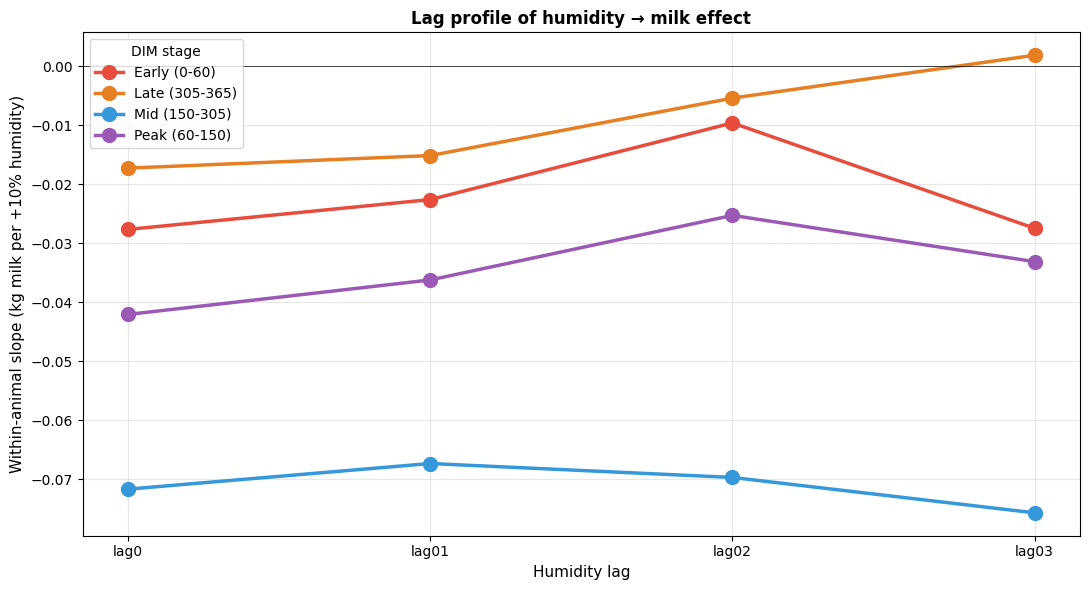

In [39]:
pivot = lag_df.pivot(index='DIM_stage', columns='lag', values='slope_per10')
print('Slope per +10% humidity (within-animal):')
print(pivot.round(4))

fig, ax = plt.subplots(figsize=(11, 6))
lags_order = ['lag0', 'lag01', 'lag02', 'lag03']
colors = ['#e74c3c', '#e67e22', '#3498db', '#9b59b6']
for color, stage in zip(colors, pivot.index):
    ax.plot(lags_order, pivot.loc[stage, lags_order].values, 'o-',
            linewidth=2.5, markersize=10, label=str(stage), color=color)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Humidity lag', fontsize=11)
ax.set_ylabel('Within-animal slope (kg milk per +10% humidity)', fontsize=11)
ax.set_title('Lag profile of humidity → milk effect', fontweight='bold')
ax.legend(title='DIM stage')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(path + 'Final_Data/humidity_lag_profile.png', dpi=150, bbox_inches='tight')
plt.show()

### 16.2 Cumulative humidity (3-day average)
The previous test treats each lag in isolation. But heat-stress literature suggests
**cumulative** humidity over several days is what matters. Test it directly.

In [40]:
# Build a 3-day average humidity (today + lag1 + lag2)
sub['humidity_avg_3d'] = sub[['humidity_avg', 'humidity_avg_lag1', 'humidity_avg_lag2']].mean(axis=1)
sub['humidity_avg_3d_dev'] = sub['humidity_avg_3d'] - sub.groupby('Animal_ID')['humidity_avg_3d'].transform('mean')

print('Within-animal slope of milk_kg vs cumulative humidity (3-day mean) per DIM stage:')
print(f"{'DIM stage':<20}{'slope_per10%':>16}{'r':>12}{'p':>14}")
print('-' * 62)
for stage in sub['DIM_stage'].cat.categories:
    s = sub[sub['DIM_stage'] == stage]
    lr = linregress(s['humidity_avg_3d_dev'], s['milk_dev'])
    print(f"{str(stage):<20}{lr.slope*10:>+16.4f}{lr.rvalue:>+12.4f}{lr.pvalue:>14.2e}")

# Compare same-day vs 3-day for each DIM stage
print('\nSame-day vs cumulative effect on Peak lactation:')
peak = sub[sub['DIM_stage'] == 'Peak (60-150)']
lr1 = linregress(peak['humidity_avg'] - peak.groupby('Animal_ID')['humidity_avg'].transform('mean'), peak['milk_dev'])
lr3 = linregress(peak['humidity_avg_3d_dev'], peak['milk_dev'])
print(f"  Same-day humidity:    slope = {lr1.slope*10:+.4f} kg per +10%   r = {lr1.rvalue:+.4f}")
print(f"  3-day mean humidity:  slope = {lr3.slope*10:+.4f} kg per +10%   r = {lr3.rvalue:+.4f}")

Within-animal slope of milk_kg vs cumulative humidity (3-day mean) per DIM stage:
DIM stage               slope_per10%           r             p
--------------------------------------------------------------
Early (0-60)                 -0.0258     -0.0091      7.80e-08
Peak (60-150)                -0.0453     -0.0177      1.76e-41
Mid (150-305)                -0.0899     -0.0386     8.77e-216
Late (305-365)               -0.0160     -0.0071      8.81e-02

Same-day vs cumulative effect on Peak lactation:
  Same-day humidity:    slope = -0.0315 kg per +10%   r = -0.0130
  3-day mean humidity:  slope = -0.0453 kg per +10%   r = -0.0177


---
# 📈 Section 17 — Non-linear Weather Effects (Spline / GAM-style)

**Goal:** No more pre-binning. Let the data tell us the **shape** of the weather effect.

**Method:** Fit a regression with **cubic splines** (5 knots) for each continuous variable.
This is mathematically equivalent to a Generalized Additive Model (GAM). It captures any
shape — thresholds, U-curves, plateaus — without forcing linearity.

**Model:**
$$\text{milk\_kg} \sim s(\text{humidity}) + s(\text{temperature}) + s(\text{DIM}) + \text{parity}$$

Then we plot the **partial dependence** of each weather variable, holding others fixed.


In [49]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import time

# Prepare data
cols_needed = ['milk_kg', 'humidity_avg', 'temperature_avg', 'DIM', 'parity', 'Animal_ID', 'Farm_Code']
data = df[cols_needed].dropna()

# Within-animal demeaning to remove between-animal selection (Section 14 lesson)
data = data.copy()
for c in ['milk_kg', 'humidity_avg', 'temperature_avg', 'DIM']:
    data[c + '_dev'] = data[c] - data.groupby('Animal_ID')[c].transform('mean')

print(f"Records: {len(data):,}")

# Using FULL dataset (spline regression is fast)
sample = data
print(f"Using full dataset: {len(sample):,}")

feat_cols = ['humidity_avg_dev', 'temperature_avg_dev', 'DIM_dev']

# Build spline + linear pipeline (within-animal residuals as both X and y)
spline = ColumnTransformer(
    transformers=[
        ('humidity_spline',    SplineTransformer(n_knots=6, degree=3), ['humidity_avg_dev']),
        ('temperature_spline', SplineTransformer(n_knots=6, degree=3), ['temperature_avg_dev']),
        ('DIM_spline',         SplineTransformer(n_knots=8, degree=3), ['DIM_dev']),
    ]
)
gam = Pipeline([('spline', spline), ('linreg', LinearRegression())])

t0 = time.time()
gam.fit(sample[feat_cols], sample['milk_kg_dev'])
print(f"Fitted in {time.time()-t0:.1f}s")

# Model fit quality
r2 = gam.score(sample[feat_cols], sample['milk_kg_dev'])
print(f"R² (within-animal): {r2:.4f}")
print(f"→ {r2*100:.2f}% of within-animal milk variance explained by weather + DIM (smoothly)")

Records: 1,646,809
Using full dataset: 1,646,809
Fitted in 2.1s
R² (within-animal): 0.4637
→ 46.37% of within-animal milk variance explained by weather + DIM (smoothly)


### 17.1 Partial Dependence — the SHAPE of each effect

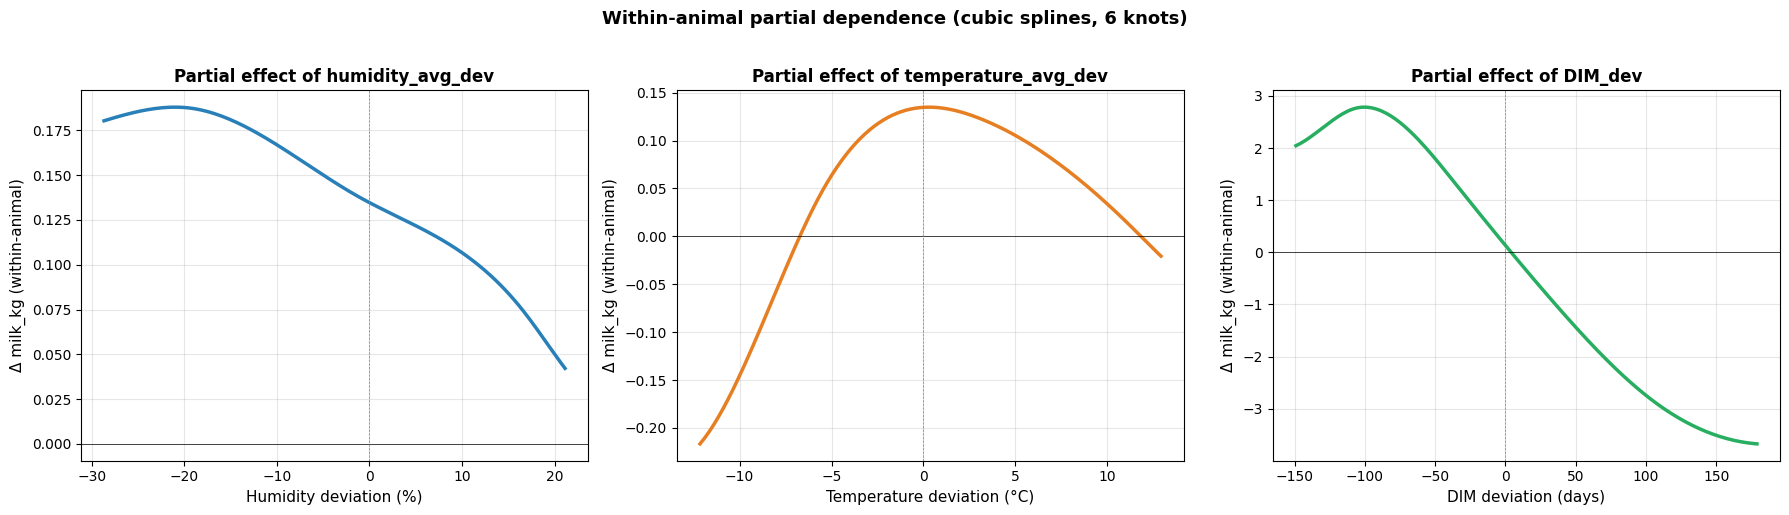

In [50]:
def partial_dependence(gam_model, sample, var, n=200, others_at='mean'):
    """Vary ONE variable across its range, hold others fixed at sample mean."""
    x_grid = np.linspace(sample[var].quantile(0.01), sample[var].quantile(0.99), n)
    X_pdp = pd.DataFrame({c: np.full(n, sample[c].mean()) for c in feat_cols})
    X_pdp[var] = x_grid
    y_pdp = gam_model.predict(X_pdp)
    return x_grid, y_pdp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('humidity_avg_dev',    'Humidity deviation (%)',    '#2980b9', axes[0]),
    ('temperature_avg_dev', 'Temperature deviation (°C)', '#e67e22', axes[1]),
    ('DIM_dev',             'DIM deviation (days)',       '#27ae60', axes[2]),
]
for var, xlabel, color, ax in configs:
    x, y = partial_dependence(gam, sample, var)
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, linestyle='--')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Δ milk_kg (within-animal)', fontsize=11)
    ax.set_title(f'Partial effect of {var}', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Within-animal partial dependence (cubic splines, 6 knots)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(path + 'Final_Data/gam_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 17.2 Quantify the spline — milk loss at key humidity values

In [51]:
# Build a clean comparison: predicted milk change at humidity_dev = X vs X=0
x_grid, y_grid = partial_dependence(gam, sample, 'humidity_avg_dev', n=500)
baseline = y_grid[np.argmin(np.abs(x_grid))]  # value at humidity_dev = 0

print('Predicted milk change vs humidity deviation from animal\'s own mean:')
print(f"{'Δ humidity':<14}{'Δ milk_kg':>14}")
print('-' * 30)
for dev in [-20, -10, -5, 0, 5, 10, 20, 30]:
    idx = np.argmin(np.abs(x_grid - dev))
    delta = y_grid[idx] - baseline
    print(f"{dev:+5d} % {'':<6}{delta:+12.4f} kg")

# Same for temperature
print('\nPredicted milk change vs temperature deviation:')
x_grid_t, y_grid_t = partial_dependence(gam, sample, 'temperature_avg_dev', n=500)
baseline_t = y_grid_t[np.argmin(np.abs(x_grid_t))]
print(f"{'Δ temp':<14}{'Δ milk_kg':>14}")
print('-' * 30)
for dev in [-10, -5, 0, 5, 10]:
    idx = np.argmin(np.abs(x_grid_t - dev))
    delta = y_grid_t[idx] - baseline_t
    print(f"{dev:+5d} °C {'':<5}{delta:+12.4f} kg")

Predicted milk change vs humidity deviation from animal's own mean:
Δ humidity         Δ milk_kg
------------------------------
  -20 %            +0.0530 kg
  -10 %            +0.0322 kg
   -5 %            +0.0154 kg
   +0 %            +0.0000 kg
   +5 %            -0.0129 kg
  +10 %            -0.0278 kg
  +20 %            -0.0848 kg
  +30 %            -0.0926 kg

Predicted milk change vs temperature deviation:
Δ temp             Δ milk_kg
------------------------------
  -10 °C           -0.2799 kg
   -5 °C           -0.0717 kg
   +0 °C           +0.0000 kg
   +5 °C           -0.0291 kg
  +10 °C           -0.1010 kg


---
# 🏗️ Section 18 — Linear Mixed-Effects Model (LMM)

**Goal:** The proper hierarchical statistical model that respects your data structure:
- 314 farms (level 3)
- ~84k animals nested in farms (level 2)
- ~1.6M records nested in animals (level 1)

**Model:**
$$\text{milk\_kg} = \beta_0 + \beta_1 \cdot \text{humidity} + \beta_2 \cdot \text{temperature} + \beta_3 \cdot \text{DIM} + \beta_4 \cdot \text{parity} + u_{\text{animal}} + \varepsilon$$

Where $u_{\text{animal}} \sim N(0, \sigma_{\text{animal}}^2)$ is the **random intercept** for each animal.

This gives:
1. **Unbiased weather coefficients** (no inflation from pseudo-replication)
2. **Proper standard errors** that account for within-animal clustering
3. **Variance decomposition**: how much is animal vs residual
4. A direct comparison with the **naive OLS** (which is wrong here)

In [52]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import time

# Subsample for speed (200k is statistically more than enough)
cols_needed = ['milk_kg', 'humidity_avg', 'temperature_avg', 'DIM', 'parity', 'Animal_ID', 'Farm_Code']
data = df[cols_needed].dropna()
# Using FULL dataset — LMM may take 10-30 minutes due to ~84k random effects
sample = data.copy()
print(f"Sample size: {len(sample):,}  (animals: {sample['Animal_ID'].nunique():,}, farms: {sample['Farm_Code'].nunique():,})")

# Step 1 — Naive OLS (the wrong way, for comparison)
print("\n=== Naive OLS (assumes independence, WRONG for hierarchical data) ===")
ols = smf.ols("milk_kg ~ humidity_avg + temperature_avg + DIM + parity", data=sample).fit()
print(ols.summary().tables[1])

# Step 2 — Mixed-Effects Model with random intercept for Animal
print("\n=== Linear Mixed Model (random intercept per Animal) ===")
t0 = time.time()
lmm = smf.mixedlm(
    "milk_kg ~ humidity_avg + temperature_avg + DIM + parity",
    data=sample,
    groups=sample['Animal_ID'],
).fit(method='lbfgs')
print(f"Fitted in {time.time() - t0:.1f}s")
print(lmm.summary())

Sample size: 1,646,809  (animals: 91,221, farms: 316)

=== Naive OLS (assumes independence, WRONG for hierarchical data) ===
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          12.5191      0.020    621.059      0.000      12.480      12.559
humidity_avg       -0.0056      0.000    -25.872      0.000      -0.006      -0.005
temperature_avg     0.0150      0.000     39.995      0.000       0.014       0.016
DIM                -0.0229   2.74e-05   -836.957      0.000      -0.023      -0.023
parity              0.0817      0.001     65.851      0.000       0.079       0.084

=== Linear Mixed Model (random intercept per Animal) ===


/Users/smsag/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Fitted in 48.9s
            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: milk_kg      
No. Observations:   1646809 Method:             REML         
No. Groups:         91221   Scale:              5.6355       
Min. group size:    3       Log-Likelihood:     -3865188.3595
Max. group size:    84      Converged:          Yes          
Mean group size:    18.1                                     
-------------------------------------------------------------
                Coef.  Std.Err.     z     P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept       12.337    0.018   674.552 0.000 12.301 12.373
humidity_avg    -0.001    0.000    -2.768 0.006 -0.001 -0.000
temperature_avg  0.009    0.000    29.610 0.000  0.009  0.010
DIM             -0.025    0.000 -1095.143 0.000 -0.025 -0.025
parity           0.027    0.001    19.670 0.000  0.024  0.029
Group Var        3.496    0.008                              



### 18.1 Variance Decomposition — how much variance is at each level?

In [53]:
var_animal   = lmm.cov_re.iloc[0, 0]
var_residual = lmm.scale
var_total    = var_animal + var_residual
icc          = var_animal / var_total

print('Variance Components:')
print(f"  σ²_animal    = {var_animal:8.4f}  ({var_animal/var_total*100:5.1f}% of total)")
print(f"  σ²_residual  = {var_residual:8.4f}  ({var_residual/var_total*100:5.1f}% of total)")
print(f"  σ²_total     = {var_total:8.4f}")
print()
print(f"ICC (animal) = {icc:.3f}")
print(f"→ {icc*100:.1f}% of milk yield variance is between animals")
print(f"→ {(1-icc)*100:.1f}% is within-animal (day-to-day variation)")
print()
print('This ICC justifies the use of a hierarchical model — naive OLS')
print('would have effectively inflated the sample size by ' + f'{1/(1-icc):.1f}x.')

Variance Components:
  σ²_animal    =   3.4958  ( 38.3% of total)
  σ²_residual  =   5.6355  ( 61.7% of total)
  σ²_total     =   9.1313

ICC (animal) = 0.383
→ 38.3% of milk yield variance is between animals
→ 61.7% is within-animal (day-to-day variation)

This ICC justifies the use of a hierarchical model — naive OLS
would have effectively inflated the sample size by 1.6x.


### 18.2 OLS vs Mixed Model — side-by-side

In [54]:
compare = pd.DataFrame({
    'OLS_coef':     [ols.params['humidity_avg'], ols.params['temperature_avg'], ols.params['DIM'], ols.params['parity']],
    'OLS_SE':       [ols.bse['humidity_avg'],   ols.bse['temperature_avg'],   ols.bse['DIM'],   ols.bse['parity']],
    'OLS_p':        [ols.pvalues['humidity_avg'], ols.pvalues['temperature_avg'], ols.pvalues['DIM'], ols.pvalues['parity']],
    'LMM_coef':     [lmm.fe_params['humidity_avg'], lmm.fe_params['temperature_avg'], lmm.fe_params['DIM'], lmm.fe_params['parity']],
    'LMM_SE':       [lmm.bse_fe['humidity_avg'], lmm.bse_fe['temperature_avg'], lmm.bse_fe['DIM'], lmm.bse_fe['parity']],
    'LMM_p':        [lmm.pvalues['humidity_avg'], lmm.pvalues['temperature_avg'], lmm.pvalues['DIM'], lmm.pvalues['parity']],
}, index=['humidity_avg', 'temperature_avg', 'DIM', 'parity'])

compare['SE_ratio'] = compare['LMM_SE'] / compare['OLS_SE']
compare['per10%_humidity'] = compare['LMM_coef'] * 10  # for humidity row interpretation

print('Coefficient comparison:')
print(compare.round(5))
print()
print('Note: SE_ratio > 1 means OLS understates uncertainty (the typical case).')

Coefficient comparison:
                 OLS_coef   OLS_SE  OLS_p  LMM_coef   LMM_SE    LMM_p  \
humidity_avg     -0.00559  0.00022    0.0  -0.00051  0.00018  0.00564   
temperature_avg   0.01504  0.00038    0.0   0.00939  0.00032  0.00000   
DIM              -0.02289  0.00003    0.0  -0.02485  0.00002  0.00000   
parity            0.08171  0.00124    0.0   0.02669  0.00136  0.00000   

                 SE_ratio  per10%_humidity  
humidity_avg      0.84686         -0.00507  
temperature_avg   0.84396          0.09395  
DIM               0.82979         -0.24855  
parity            1.09345          0.26689  

Note: SE_ratio > 1 means OLS understates uncertainty (the typical case).


### 18.3 Farm-level random effect (control for farm clustering)

In [55]:
# Now use Farm_Code as grouping instead, to see how much weather effect comes
# from comparing across farms vs within farms
print('=== LMM with Farm_Code as random effect ===')
t0 = time.time()
lmm_farm = smf.mixedlm(
    "milk_kg ~ humidity_avg + temperature_avg + DIM + parity",
    data=sample,
    groups=sample['Farm_Code'],
).fit(method='lbfgs')
print(f"Fitted in {time.time() - t0:.1f}s")

farm_var = lmm_farm.cov_re.iloc[0, 0]
print(f"\nσ²_farm     = {farm_var:.4f}")
print(f"σ²_residual = {lmm_farm.scale:.4f}")
print(f"ICC (farm)  = {farm_var / (farm_var + lmm_farm.scale):.3f}")
print(f"→ {farm_var / (farm_var + lmm_farm.scale)*100:.1f}% of variance is BETWEEN farms")
print()
print('Fixed effects under Farm-level random intercept:')
print(lmm_farm.summary().tables[1])

=== LMM with Farm_Code as random effect ===


/Users/smsag/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Fitted in 3.8s

σ²_farm     = 1.2527
σ²_residual = 7.5173
ICC (farm)  = 0.143
→ 14.3% of variance is BETWEEN farms

Fixed effects under Farm-level random intercept:
                  Coef. Std.Err.         z  P>|z|  [0.025  0.975]
Intercept        12.139    0.066   183.756  0.000  12.009  12.268
humidity_avg     -0.003    0.000   -14.945  0.000  -0.003  -0.003
temperature_avg   0.009    0.000    25.852  0.000   0.009   0.010
DIM              -0.023    0.000  -918.369  0.000  -0.023  -0.023
parity            0.074    0.001    62.805  0.000   0.072   0.077
Group Var         1.253    0.037                                 


### 18.4 Final Comparison Table — three perspectives on humidity

In [56]:
final = pd.DataFrame({
    'OLS (naive)':            [ols.params['humidity_avg'],      ols.bse['humidity_avg'],      ols.pvalues['humidity_avg']],
    'LMM (animal random)':    [lmm.fe_params['humidity_avg'],   lmm.bse_fe['humidity_avg'],   lmm.pvalues['humidity_avg']],
    'LMM (farm random)':      [lmm_farm.fe_params['humidity_avg'], lmm_farm.bse_fe['humidity_avg'], lmm_farm.pvalues['humidity_avg']],
}, index=['humidity_coef', 'SE', 'p-value']).T

final['per10%_milk_loss'] = final['humidity_coef'] * 10
final['CI95_low_per10']   = (final['humidity_coef'] - 1.96 * final['SE']) * 10
final['CI95_high_per10']  = (final['humidity_coef'] + 1.96 * final['SE']) * 10

print('Humidity effect on milk_kg — three models compared:')
print(final.round(5))
print()
print('Interpretation:')
for model_name in final.index:
    print(f"  {model_name}:")
    print(f"    +10% humidity → {final.loc[model_name,'per10%_milk_loss']:+.4f} kg milk")
    print(f"    95% CI: [{final.loc[model_name,'CI95_low_per10']:+.4f}, "
          f"{final.loc[model_name,'CI95_high_per10']:+.4f}] kg")

Humidity effect on milk_kg — three models compared:
                     humidity_coef       SE  p-value  per10%_milk_loss  \
OLS (naive)               -0.00559  0.00022  0.00000          -0.05591   
LMM (animal random)       -0.00051  0.00018  0.00564          -0.00507   
LMM (farm random)         -0.00309  0.00021  0.00000          -0.03089   

                     CI95_low_per10  CI95_high_per10  
OLS (naive)                -0.06015         -0.05167  
LMM (animal random)        -0.00865         -0.00148  
LMM (farm random)          -0.03494         -0.02684  

Interpretation:
  OLS (naive):
    +10% humidity → -0.0559 kg milk
    95% CI: [-0.0601, -0.0517] kg
  LMM (animal random):
    +10% humidity → -0.0051 kg milk
    95% CI: [-0.0087, -0.0015] kg
  LMM (farm random):
    +10% humidity → -0.0309 kg milk
    95% CI: [-0.0349, -0.0268] kg


---
# 🌡️❄️ Section 19 — Heat Wave & Cold Snap Event Analysis

**Goal:** Detect multi-day extreme weather events (heat waves, cold snaps) at the daily level
from the per-farm weather files, then measure their impact on milk yield.

**Definitions (from buffalo literature):**
| Event | Threshold | Min duration |
|---|---|---|
| Heat Wave | `THI_1_avg > 78` (3+ days) | Petrocchi 2023 |
| Severe Heat Wave | `THI_1_avg > 82` (3+ days) | — |
| Cold Snap | `THI_1_avg < 50` (3+ days) | Matera 2022 |
| Severe Cold Snap | `temperature_avg < 0°C` (3+ days) | — |

## 19.1 Load Daily Weather & Detect Events

In [65]:
from pathlib import Path
import time

# --- Load all per-farm daily weather files ---
weather_folder = Path(path + 'farm_weather_indices')
weather_files = list(weather_folder.glob('farm_*_with_indices.csv'))
print(f"Found {len(weather_files)} weather files")

t0 = time.time()
dfs = []
for wf in weather_files:
    parts = wf.stem.split('_')
    farm_code = None
    for part in parts[1:]:
        clean = part.replace('.0', '').replace('.', '')
        if clean.isdigit():
            farm_code = int(clean)
            break
    if farm_code is None:
        continue
    wdf = pd.read_csv(wf, usecols=['date', 'temperature_avg', 'THI_1_avg'])
    wdf['Farm_Code'] = farm_code
    dfs.append(wdf)

weather = pd.concat(dfs, ignore_index=True)
weather['date'] = pd.to_datetime(weather['date'])
weather = weather.sort_values(['Farm_Code', 'date']).reset_index(drop=True)
print(f"Loaded in {time.time()-t0:.1f}s — {len(weather):,} farm-days, {weather['Farm_Code'].nunique()} farms")
print(f"Date range: {weather['date'].min().date()} → {weather['date'].max().date()}")

Found 329 weather files
Loaded in 1.8s — 1,562,421 farm-days, 329 farms
Date range: 2012-12-31 → 2025-12-31


## 19.2 Event Detection (consecutive-day runs)

In [66]:
# Thresholds
HEATWAVE_THI    = 78
SEV_HEATWAVE_THI = 82
COLDSNAP_THI    = 50
SEV_COLDSNAP_T  = 0
MIN_DURATION    = 3

# Indicator days
weather['hot_day']      = (weather['THI_1_avg'] > HEATWAVE_THI).astype(int)
weather['sev_hot_day']  = (weather['THI_1_avg'] > SEV_HEATWAVE_THI).astype(int)
weather['cold_day']     = (weather['THI_1_avg'] < COLDSNAP_THI).astype(int)
weather['sev_cold_day'] = (weather['temperature_avg'] < SEV_COLDSNAP_T).astype(int)

def mark_events(df, indicator_col, event_col, min_dur=3):
    """Mark days as part of an event of length >= min_dur."""
    # Detect runs using cumsum on diff
    df['_change'] = df.groupby('Farm_Code')[indicator_col].diff().fillna(0).ne(0).cumsum()
    df['_run_len'] = df.groupby(['Farm_Code', '_change'])[indicator_col].transform('size')
    df[event_col] = ((df[indicator_col] == 1) & (df['_run_len'] >= min_dur)).astype(int)
    # Day number within event (1, 2, 3, ...)
    day_col = event_col.replace('in_', '') + '_day'  # e.g. in_heatwave -> heatwave_day
    df[day_col] = df.groupby(['Farm_Code', '_change']).cumcount() + 1
    df.loc[df[event_col] == 0, day_col] = 0
    df.drop(columns=['_change', '_run_len'], inplace=True)
    return df

t0 = time.time()
weather = mark_events(weather, 'hot_day',      'in_heatwave',     MIN_DURATION)
weather = mark_events(weather, 'sev_hot_day',  'in_sev_heatwave', MIN_DURATION)
weather = mark_events(weather, 'cold_day',     'in_coldsnap',     MIN_DURATION)
weather = mark_events(weather, 'sev_cold_day', 'in_sev_coldsnap', MIN_DURATION)
print(f"Event detection done in {time.time()-t0:.1f}s")

# Summary
print(f"\n=== Event Summary (over all farms × days) ===")
print(f"Heat-wave days:        {weather['in_heatwave'].sum():>9,} ({weather['in_heatwave'].mean()*100:.1f}%)")
print(f"Severe heat-wave days: {weather['in_sev_heatwave'].sum():>9,} ({weather['in_sev_heatwave'].mean()*100:.1f}%)")
print(f"Cold-snap days:        {weather['in_coldsnap'].sum():>9,} ({weather['in_coldsnap'].mean()*100:.1f}%)")
print(f"Severe cold-snap days: {weather['in_sev_coldsnap'].sum():>9,} ({weather['in_sev_coldsnap'].mean()*100:.1f}%)")

Event detection done in 0.5s

=== Event Summary (over all farms × days) ===
Heat-wave days:           19,387 (1.2%)
Severe heat-wave days:         0 (0.0%)
Cold-snap days:          246,358 (15.8%)
Severe cold-snap days:     1,318 (0.1%)


## 19.3 Compute Recovery & Cumulative Features

In [67]:
# Heat-wave end days
weather['heatwave_end'] = (
    (weather['in_heatwave'] == 1) &
    (weather.groupby('Farm_Code')['in_heatwave'].shift(-1).fillna(0) == 0)
).astype(int)
weather['coldsnap_end'] = (
    (weather['in_coldsnap'] == 1) &
    (weather.groupby('Farm_Code')['in_coldsnap'].shift(-1).fillna(0) == 0)
).astype(int)

# Days since last event ended (forward-fill end date)
def days_since_event(df, end_col, new_col):
    df['_last_end'] = df['date'].where(df[end_col] == 1)
    df['_last_end'] = df.groupby('Farm_Code')['_last_end'].ffill()
    df[new_col] = (df['date'] - df['_last_end']).dt.days
    df.drop(columns=['_last_end'], inplace=True)
    return df

weather = days_since_event(weather, 'heatwave_end', 'days_since_heatwave')
weather = days_since_event(weather, 'coldsnap_end', 'days_since_coldsnap')

# Rolling counts (past 30 days)
weather['heatwave_days_past_30d'] = (
    weather.groupby('Farm_Code')['in_heatwave']
    .transform(lambda x: x.rolling(30, min_periods=1).sum())
)
weather['coldsnap_days_past_30d'] = (
    weather.groupby('Farm_Code')['in_coldsnap']
    .transform(lambda x: x.rolling(30, min_periods=1).sum())
)

# Peak THI past 7 days
weather['max_THI_past_7d'] = (
    weather.groupby('Farm_Code')['THI_1_avg']
    .transform(lambda x: x.rolling(7, min_periods=1).max())
)
weather['min_T_past_7d'] = (
    weather.groupby('Farm_Code')['temperature_avg']
    .transform(lambda x: x.rolling(7, min_periods=1).min())
)

print("Event features computed.")
print(weather[['Farm_Code','date','in_heatwave','heatwave_day','days_since_heatwave',
               'heatwave_days_past_30d','in_coldsnap','days_since_coldsnap']].head(10))

Event features computed.
   Farm_Code       date  in_heatwave  heatwave_day  days_since_heatwave  \
0     521513 2012-12-31            0             0                  NaN   
1     521513 2013-01-01            0             0                  NaN   
2     521513 2013-01-02            0             0                  NaN   
3     521513 2013-01-03            0             0                  NaN   
4     521513 2013-01-04            0             0                  NaN   
5     521513 2013-01-05            0             0                  NaN   
6     521513 2013-01-06            0             0                  NaN   
7     521513 2013-01-07            0             0                  NaN   
8     521513 2013-01-08            0             0                  NaN   
9     521513 2013-01-09            0             0                  NaN   

   heatwave_days_past_30d  in_coldsnap  days_since_coldsnap  
0                     0.0            1                  NaN  
1                     0.0

## 19.4 Merge Events into Test Records

In [68]:
# Make sure dtt in test data is parsed as datetime
df['dtt_date'] = pd.to_datetime(df['dtt']).dt.normalize()

event_cols = ['Farm_Code', 'date',
              'in_heatwave', 'heatwave_day', 'days_since_heatwave', 'heatwave_days_past_30d',
              'in_sev_heatwave',
              'in_coldsnap', 'coldsnap_day', 'days_since_coldsnap', 'coldsnap_days_past_30d',
              'in_sev_coldsnap',
              'max_THI_past_7d', 'min_T_past_7d']

df_ev = df.merge(weather[event_cols],
                 left_on=['Farm_Code', 'dtt_date'],
                 right_on=['Farm_Code', 'date'],
                 how='left').drop(columns=['date'])

# Quick sanity check
print(f"Total test records:                {len(df_ev):,}")
print(f"Matched with weather:              {df_ev['in_heatwave'].notna().sum():,}")
print(f"Test records DURING heat wave:     {(df_ev['in_heatwave'] == 1).sum():,}")
print(f"Test records DURING cold snap:     {(df_ev['in_coldsnap'] == 1).sum():,}")
print(f"Test records DURING severe heat:   {(df_ev['in_sev_heatwave'] == 1).sum():,}")
print(f"Test records DURING severe cold:   {(df_ev['in_sev_coldsnap'] == 1).sum():,}")

# Add DIM stage
df_ev['DIM_stage'] = pd.cut(df_ev['DIM'], bins=[0, 60, 150, 305, 365],
                            labels=['Early', 'Peak', 'Mid', 'Late'])

Total test records:                1,646,809
Matched with weather:              1,646,809
Test records DURING heat wave:     19,799
Test records DURING cold snap:     250,025
Test records DURING severe heat:   0
Test records DURING severe cold:   1,749


## 19.5 Analysis 1 — Within-Animal Milk Yield: In vs Out of Heat Wave

In [69]:
# Within-animal: keep only animals with at least one in-event and one out-of-event test
def within_animal_compare(df_ev, event_col, label):
    sub = df_ev[['Animal_ID', 'DIM_stage', 'milk_kg', event_col]].dropna()
    # For each animal, check whether they have records both in and out of event
    grp_means = sub.groupby(['Animal_ID', event_col])['milk_kg'].mean().unstack()

    # Make sure both columns (0 = out, 1 = in) exist
    for col in [0, 1]:
        if col not in grp_means.columns:
            grp_means[col] = np.nan
    grp_means = grp_means[[0, 1]]
    grp_means.columns = [f'{label}_out', f'{label}_in']

    # Keep only animals that have BOTH in and out records
    grp_means = grp_means.dropna()
    print(f"\n=== {label.upper()} (within-animal paired analysis) ===")
    if len(grp_means) == 0:
        print(f"  ⚠️ No animals have both in-event and out-of-event records — event too rare to analyse")
        return grp_means

    grp_means[f'delta_{label}'] = grp_means[f'{label}_in'] - grp_means[f'{label}_out']

    print(f"Animals with both in & out records: {len(grp_means):,}")
    print(f"Mean milk OUT of {label}:  {grp_means[f'{label}_out'].mean():.3f} kg")
    print(f"Mean milk DURING {label}:  {grp_means[f'{label}_in'].mean():.3f} kg")
    delta = grp_means[f'delta_{label}'].mean()
    print(f"Mean within-animal Δ:      {delta:+.3f} kg ({delta/grp_means[f'{label}_out'].mean()*100:+.2f}%)")
    print(f"% animals with negative Δ: {(grp_means[f'delta_{label}'] < 0).mean()*100:.1f}%")
    # paired t-test
    from scipy.stats import ttest_rel
    t, p = ttest_rel(grp_means[f'{label}_in'], grp_means[f'{label}_out'])
    print(f"Paired t-test: t = {t:.2f}, p = {p:.2e}")
    return grp_means

hw = within_animal_compare(df_ev, 'in_heatwave',     'heatwave')
sw = within_animal_compare(df_ev, 'in_sev_heatwave', 'sev_heatwave')
cs = within_animal_compare(df_ev, 'in_coldsnap',     'coldsnap')
sc = within_animal_compare(df_ev, 'in_sev_coldsnap', 'sev_coldsnap')


=== HEATWAVE (within-animal paired analysis) ===
Animals with both in & out records: 17,752
Mean milk OUT of heatwave:  9.364 kg
Mean milk DURING heatwave:  9.224 kg
Mean within-animal Δ:      -0.140 kg (-1.49%)
% animals with negative Δ: 54.0%
Paired t-test: t = -6.27, p = 3.75e-10

=== SEV_HEATWAVE (within-animal paired analysis) ===
  ⚠️ No animals have both in-event and out-of-event records — event too rare to analyse

=== COLDSNAP (within-animal paired analysis) ===
Animals with both in & out records: 69,218
Mean milk OUT of coldsnap:  9.131 kg
Mean milk DURING coldsnap:  8.783 kg
Mean within-animal Δ:      -0.348 kg (-3.81%)
% animals with negative Δ: 55.8%
Paired t-test: t = -33.99, p = 3.20e-251

=== SEV_COLDSNAP (within-animal paired analysis) ===
Animals with both in & out records: 1,535
Mean milk OUT of sev_coldsnap:  8.632 kg
Mean milk DURING sev_coldsnap:  8.522 kg
Mean within-animal Δ:      -0.110 kg (-1.27%)
% animals with negative Δ: 52.7%
Paired t-test: t = -1.39, p =

## 19.6 Heat Wave / Cold Snap Effect by DIM Stage

In [70]:
def event_by_dim(df_ev, event_col, label):
    sub = df_ev[['Animal_ID', 'DIM_stage', 'milk_kg', event_col]].dropna()
    rows = []
    for stage in ['Early', 'Peak', 'Mid', 'Late']:
        s = sub[sub['DIM_stage'] == stage]
        grp_means = s.groupby(['Animal_ID', event_col])['milk_kg'].mean().unstack()
        # Ensure both columns exist
        for col in [0, 1]:
            if col not in grp_means.columns:
                grp_means[col] = np.nan
        grp_means = grp_means[[0, 1]].dropna()
        if len(grp_means) == 0:
            rows.append({'DIM_stage': stage, 'n_animals': 0,
                         'milk_out': np.nan, 'milk_in': np.nan,
                         'delta_kg': np.nan, 'delta_pct': np.nan})
            continue
        m_out, m_in = grp_means.iloc[:, 0].mean(), grp_means.iloc[:, 1].mean()
        delta = m_in - m_out
        rows.append({
            'DIM_stage': stage, 'n_animals': len(grp_means),
            'milk_out': m_out, 'milk_in': m_in,
            'delta_kg': delta, 'delta_pct': delta/m_out*100 if m_out else np.nan,
        })
    return pd.DataFrame(rows)

print("HEAT WAVE — by DIM stage:")
print(event_by_dim(df_ev, 'in_heatwave', 'heatwave').round(3).to_string(index=False))
print("\nSEVERE HEAT WAVE — by DIM stage:")
print(event_by_dim(df_ev, 'in_sev_heatwave', 'sev_heatwave').round(3).to_string(index=False))
print("\nCOLD SNAP — by DIM stage:")
print(event_by_dim(df_ev, 'in_coldsnap', 'coldsnap').round(3).to_string(index=False))
print("\nSEVERE COLD SNAP — by DIM stage:")
print(event_by_dim(df_ev, 'in_sev_coldsnap', 'sev_coldsnap').round(3).to_string(index=False))

HEAT WAVE — by DIM stage:
DIM_stage  n_animals  milk_out  milk_in  delta_kg  delta_pct
    Early       3225    11.641   11.610    -0.032     -0.271
     Peak       6153    10.664   10.409    -0.255     -2.392
      Mid       7954     7.415    7.677     0.263      3.545
     Late        361     6.455    5.974    -0.481     -7.458

SEVERE HEAT WAVE — by DIM stage:
DIM_stage  n_animals  milk_out  milk_in  delta_kg  delta_pct
    Early          0       NaN      NaN       NaN        NaN
     Peak          0       NaN      NaN       NaN        NaN
      Mid          0       NaN      NaN       NaN        NaN
     Late          0       NaN      NaN       NaN        NaN

COLD SNAP — by DIM stage:
DIM_stage  n_animals  milk_out  milk_in  delta_kg  delta_pct
    Early      30441    11.744   11.398    -0.345     -2.939
     Peak      32367    10.274   10.068    -0.206     -2.003
      Mid      42526     7.294    7.179    -0.115     -1.571
     Late       5699     5.776    5.831     0.055      0.95

## 19.7 Recovery Curve — Milk Yield After Heat Wave Ends

Recovery profile (within-animal deviation):
  days_bin        n  milk_mean  milk_dev_mean  milk_dev_sem
0   DURING     3559      9.384         -0.221         0.047
1      0-7    20579      9.981          0.118         0.021
2     8-14     8974      9.719         -0.004         0.031
3    15-21    10856      9.622         -0.087         0.029
4    22-30    22547      9.442         -0.062         0.020
5    31-60    99402      9.422         -0.063         0.010
6    61-90    88628      9.124         -0.347         0.010
7      90+  1056812      9.422          0.027         0.003


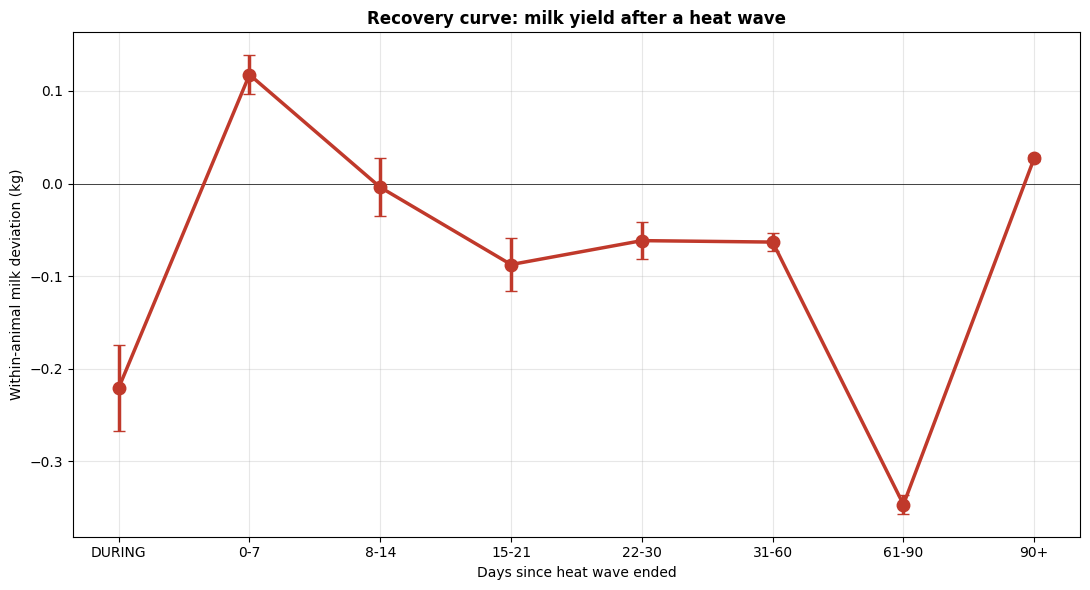

In [71]:
# Bin records by days since the most recent heat wave end
recovery = df_ev[['Animal_ID', 'milk_kg', 'days_since_heatwave', 'DIM_stage']].dropna()
recovery['days_bin'] = pd.cut(recovery['days_since_heatwave'],
                              bins=[-1, 0, 7, 14, 21, 30, 60, 90, 1000],
                              labels=['DURING','0-7','8-14','15-21','22-30','31-60','61-90','90+'])

# Within-animal deviation from animal mean
recovery['milk_dev'] = recovery['milk_kg'] - recovery.groupby('Animal_ID')['milk_kg'].transform('mean')

agg = recovery.groupby('days_bin', observed=True).agg(
    n=('milk_kg', 'size'),
    milk_mean=('milk_kg', 'mean'),
    milk_dev_mean=('milk_dev', 'mean'),
    milk_dev_sem=('milk_dev', lambda x: x.std()/np.sqrt(len(x))),
).reset_index()
print('Recovery profile (within-animal deviation):')
print(agg.round(3))

fig, ax = plt.subplots(figsize=(11, 6))
ax.errorbar(agg['days_bin'].astype(str), agg['milk_dev_mean'], yerr=agg['milk_dev_sem'],
            fmt='o-', color='#c0392b', linewidth=2.5, markersize=9, capsize=4)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Days since heat wave ended')
ax.set_ylabel('Within-animal milk deviation (kg)')
ax.set_title('Recovery curve: milk yield after a heat wave', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(path + 'Final_Data/heatwave_recovery_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 19.8 Cumulative Effect — Day-Into-Heatwave

Milk yield by day into heat wave (within-animal deviation):
   day_capped     n  milk_mean  milk_dev_mean  milk_dev_sem
0           1  4925      9.721         -0.012         0.014
1           2  3611      9.295          0.033         0.013
2           3  2856      9.021         -0.067         0.017
3           4  1431      9.374         -0.002         0.017
4           5  1458      9.081          0.007         0.013
5           6  1560      8.939          0.010         0.020
6           7  3958      8.922          0.026         0.013


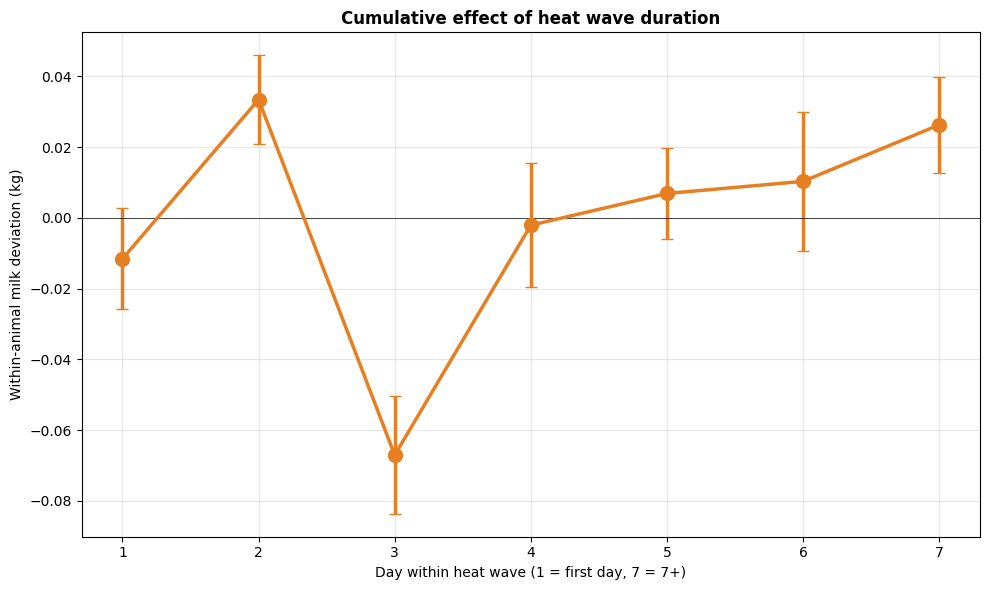

In [72]:
# Group records by which day of a heat wave they fall on
inhw = df_ev[df_ev['in_heatwave'] == 1][['Animal_ID', 'milk_kg', 'heatwave_day']].dropna()
inhw['milk_dev'] = inhw['milk_kg'] - inhw.groupby('Animal_ID')['milk_kg'].transform('mean')

# Cap at day 7+ (longer events are rare)
inhw['day_capped'] = inhw['heatwave_day'].clip(upper=7).astype(int)

cum = inhw.groupby('day_capped').agg(
    n=('milk_kg', 'size'),
    milk_mean=('milk_kg', 'mean'),
    milk_dev_mean=('milk_dev', 'mean'),
    milk_dev_sem=('milk_dev', lambda x: x.std()/np.sqrt(len(x))),
).reset_index()
print('Milk yield by day into heat wave (within-animal deviation):')
print(cum.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(cum['day_capped'], cum['milk_dev_mean'], yerr=cum['milk_dev_sem'],
            fmt='o-', color='#e67e22', linewidth=2.5, markersize=10, capsize=4)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Day within heat wave (1 = first day, 7 = 7+)')
ax.set_ylabel('Within-animal milk deviation (kg)')
ax.set_title('Cumulative effect of heat wave duration', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(path + 'Final_Data/heatwave_cumulative_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 19.9 Cold Snap — Recovery & Cumulative (same analyses, mirror)

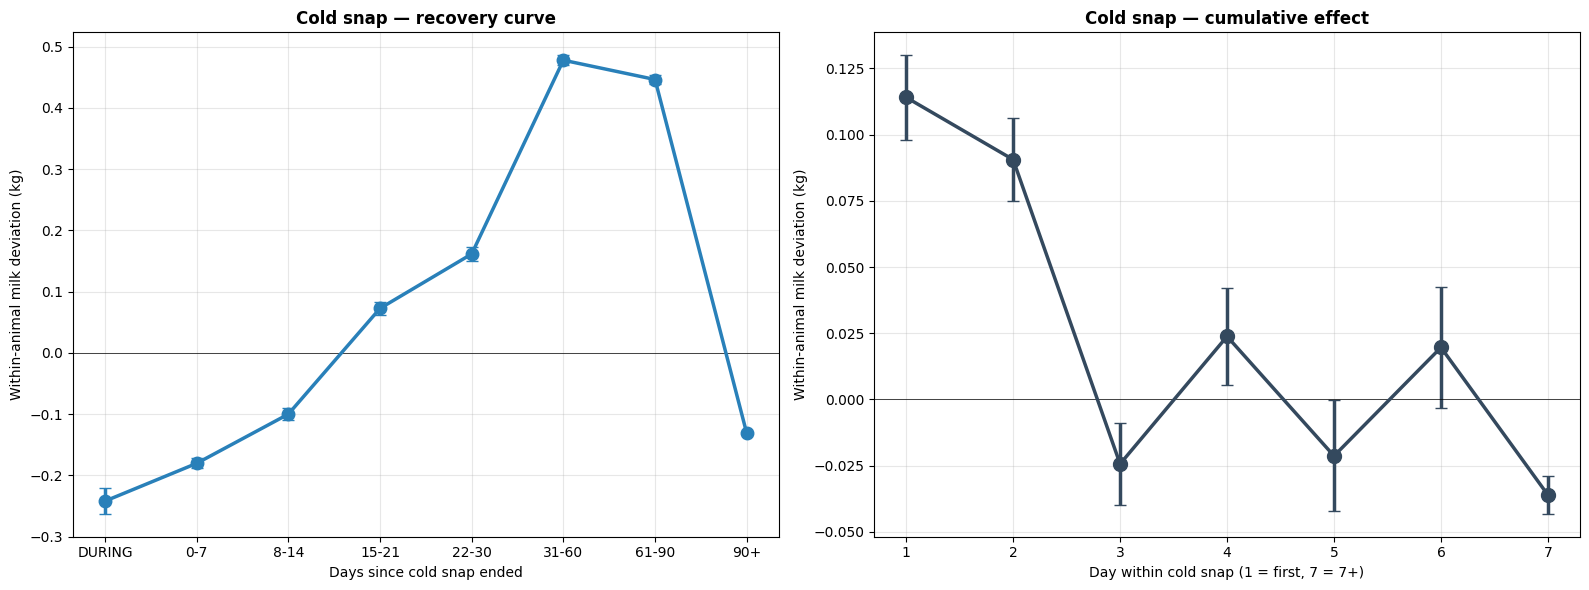


Cold snap recovery:
  days_bin       n  milk_dev_mean  milk_dev_sem
0   DURING   23064         -0.242         0.021
1      0-7  149804         -0.180         0.008
2     8-14  101206         -0.100         0.010
3    15-21   86153          0.073         0.011
4    22-30   79442          0.162         0.011
5    31-60  156927          0.478         0.008
6    61-90  149269          0.446         0.008
7      90+  898798         -0.131         0.003

Cold snap cumulative:
   day_capped       n  milk_dev_mean  milk_dev_sem
0           1   24253          0.114         0.016
1           2   24391          0.091         0.016
2           3   26775         -0.024         0.015
3           4   18652          0.024         0.018
4           5   14790         -0.021         0.021
5           6   11478          0.020         0.023
6           7  129686         -0.036         0.007


In [73]:
# Cold snap recovery
recovery_cs = df_ev[['Animal_ID', 'milk_kg', 'days_since_coldsnap']].dropna()
recovery_cs['days_bin'] = pd.cut(recovery_cs['days_since_coldsnap'],
                                 bins=[-1, 0, 7, 14, 21, 30, 60, 90, 1000],
                                 labels=['DURING','0-7','8-14','15-21','22-30','31-60','61-90','90+'])
recovery_cs['milk_dev'] = recovery_cs['milk_kg'] - recovery_cs.groupby('Animal_ID')['milk_kg'].transform('mean')
agg_cs = recovery_cs.groupby('days_bin', observed=True).agg(
    n=('milk_kg', 'size'),
    milk_dev_mean=('milk_dev', 'mean'),
    milk_dev_sem=('milk_dev', lambda x: x.std()/np.sqrt(len(x))),
).reset_index()

# Cold snap cumulative
incs = df_ev[df_ev['in_coldsnap'] == 1][['Animal_ID', 'milk_kg', 'coldsnap_day']].dropna()
incs['milk_dev'] = incs['milk_kg'] - incs.groupby('Animal_ID')['milk_kg'].transform('mean')
incs['day_capped'] = incs['coldsnap_day'].clip(upper=7).astype(int)
cum_cs = incs.groupby('day_capped').agg(
    n=('milk_kg', 'size'),
    milk_dev_mean=('milk_dev', 'mean'),
    milk_dev_sem=('milk_dev', lambda x: x.std()/np.sqrt(len(x))),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].errorbar(agg_cs['days_bin'].astype(str), agg_cs['milk_dev_mean'], yerr=agg_cs['milk_dev_sem'],
                 fmt='o-', color='#2980b9', linewidth=2.5, markersize=9, capsize=4)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xlabel('Days since cold snap ended')
axes[0].set_ylabel('Within-animal milk deviation (kg)')
axes[0].set_title('Cold snap — recovery curve', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].errorbar(cum_cs['day_capped'], cum_cs['milk_dev_mean'], yerr=cum_cs['milk_dev_sem'],
                 fmt='o-', color='#34495e', linewidth=2.5, markersize=10, capsize=4)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xlabel('Day within cold snap (1 = first, 7 = 7+)')
axes[1].set_ylabel('Within-animal milk deviation (kg)')
axes[1].set_title('Cold snap — cumulative effect', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(path + 'Final_Data/coldsnap_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCold snap recovery:'); print(agg_cs.round(3))
print('\nCold snap cumulative:'); print(cum_cs.round(3))

## 19.10 Final Summary — All Event Types Side-by-Side

Within-animal milk yield change DURING extreme events:
           Event  n_animals  delta_kg  delta_pct
       Heat wave      17752    -0.140     -1.492
Severe heat wave          0       NaN        NaN
       Cold snap      69218    -0.348     -3.807
Severe cold snap       1535    -0.110     -1.271


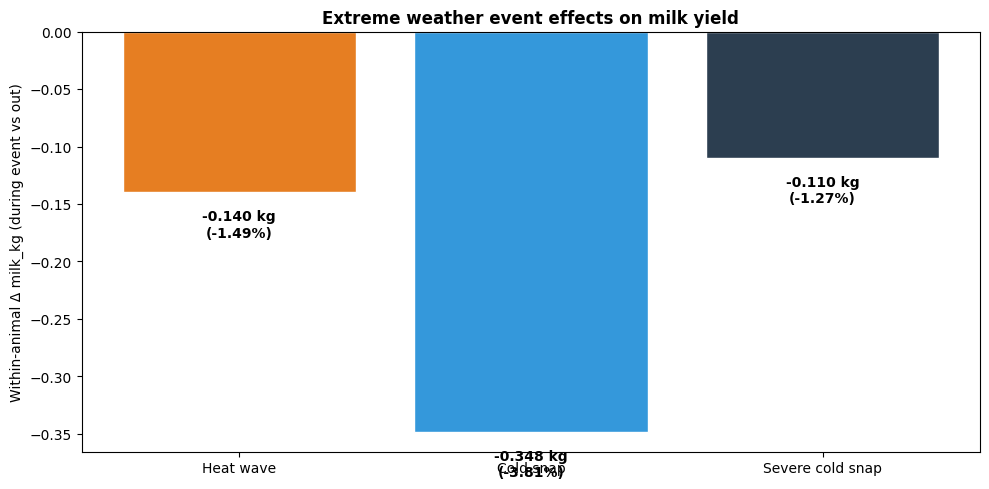

In [74]:
def safe_event_row(name, df, in_col, out_col, delta_col):
    if len(df) == 0:
        return {'Event': name, 'n_animals': 0, 'delta_kg': np.nan, 'delta_pct': np.nan}
    return {
        'Event': name,
        'n_animals': len(df),
        'delta_kg': df[delta_col].mean(),
        'delta_pct': df[delta_col].mean() / df[out_col].mean() * 100 if df[out_col].mean() else np.nan,
    }

summary = pd.DataFrame([
    safe_event_row('Heat wave',        hw, 'heatwave_in',     'heatwave_out',     'delta_heatwave'),
    safe_event_row('Severe heat wave', sw, 'sev_heatwave_in', 'sev_heatwave_out', 'delta_sev_heatwave'),
    safe_event_row('Cold snap',        cs, 'coldsnap_in',     'coldsnap_out',     'delta_coldsnap'),
    safe_event_row('Severe cold snap', sc, 'sev_coldsnap_in', 'sev_coldsnap_out', 'delta_sev_coldsnap'),
]).round(3)
print('Within-animal milk yield change DURING extreme events:')
print(summary.to_string(index=False))

# Plot — skip events that had no data
plot_df = summary.dropna(subset=['delta_kg'])
fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {'Heat wave':'#e67e22', 'Severe heat wave':'#c0392b',
              'Cold snap':'#3498db', 'Severe cold snap':'#2c3e50'}
colors = [colors_map.get(e, 'gray') for e in plot_df['Event']]
bars = ax.bar(plot_df['Event'], plot_df['delta_kg'], color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Within-animal Δ milk_kg (during event vs out)')
ax.set_title('Extreme weather event effects on milk yield', fontweight='bold')
for bar, val, pct in zip(bars, plot_df['delta_kg'], plot_df['delta_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.005 if val >= 0 else -0.015),
            f'{val:+.3f} kg\n({pct:+.2f}%)',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'Final_Data/event_summary.png', dpi=150, bbox_inches='tight')
plt.show()